# 📘 CH08. 데이터 시각화 — 강의용 노트북

정규 4시간 수업 진행용입니다. Notion(md) 문서와 동일한 깊이로 구성했습니다.

> 📂 **실습 파일 안내**: 아주 기초적인 첫 예시(2~3개 값)만 직접 입력하고, 그 이후부터는 **타이타닉 생존자 데이터**(`titanic.csv`, 실제 승객 891명의 기록)를 사용합니다. `titanic.csv`를 노트북과 같은 위치에 업로드해주세요.
>
> 🚢 타이타닉 데이터는 생존 여부, 나이, 성별, 좌석 등급, 요금 등 다양한 정보를 담고 있어 "여성과 아이 먼저", "1등석일수록 생존율이 높았다" 같은 실제 역사적 사실을 데이터로 직접 확인해볼 수 있는, 데이터 시각화 실습에서 가장 널리 쓰이는 데이터셋입니다.

---

### ☀️ 참고 ☀️ 한글깨짐 방지

- 아래 코드셀 3개 실행 필수
- 윈도우, 맥 동일

❗️주의❗️
- Step1. 첫째 셀 실행
- Step2. '런타임 > 세션 다시시작'
- Step3. 이후 두번째 셀 실행

In [2]:
# 나눔 폰트 설치
# 해당 셀 실행 후 '런타임 > 세션 다시 시작'

%%capture

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def set_korean_font():
    """Sets NanumGothic font for Matplotlib and handles minus sign issues."""
    plt.rcParams["font.family"] = "NanumGothic"
    mpl.rcParams['axes.unicode_minus'] = False

# Apply Korean font settings initially
set_korean_font()

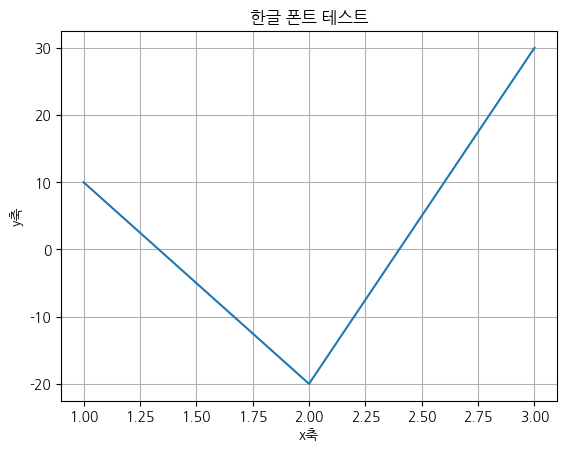

In [2]:
# 한글 폰트 테스트 그래프

plt.plot([1, 2, 3], [10, -20, 30])
plt.title('한글 폰트 테스트')
plt.xlabel('x축')
plt.ylabel('y축')
plt.grid(True)
set_korean_font()
plt.show()

# 📘 CH08-01. Matplotlib 기초

## 🤔 먼저 생각해보기

> **"연령대별 생존율"을 숫자 표로만 보는 것과, 꺾은선 그래프로 보는 것 중 어느 쪽이 "어떤 나이대가 더 많이 살아남았는지" 더 빨리 파악될까요?**

표로 나열된 숫자보다 그래프 하나가 훨씬 직관적으로 데이터의 흐름을 보여줍니다. 파이썬에서 가장 널리 쓰이는 시각화 라이브러리가 **Matplotlib**입니다.

---

## 📖 핵심 개념

### 1) Matplotlib이란? — 파이썬 시각화의 표준

- 파이썬에서 가장 오래되고 널리 쓰이는 시각화 라이브러리
- `matplotlib.pyplot`을 `plt`라는 별칭으로 불러와 사용하는 것이 관례
- 아래는 `plt.plot()`의 가장 기본적인 사용법을 보여주는 최소 예시입니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import matplotlib.pyplot as plt   # 관례적으로 plt라는 별칭 사용

x = [1, 2, 3]
y = [10, 15, 8]

plt.plot(x, y)
plt.show()
```

</details>

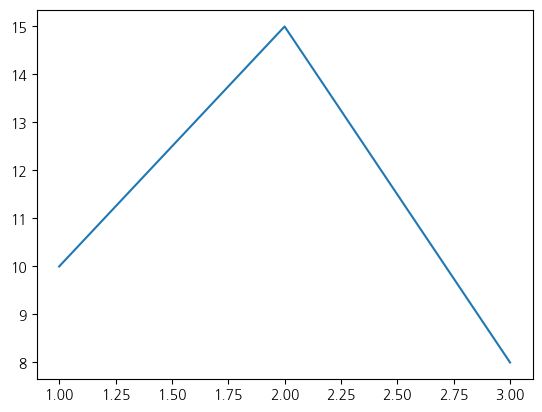

In [3]:
# 관례적으로 plt라는 별칭 사용
# 그래프를 plot이라고 한다.
import matplotlib.pyplot as plt

x = [1,2,3]
y = [10,15,8]

plt.plot(x,y)
plt.show()


### 2) 선 그래프 — `plt.plot()`

이제부터는 실제 타이타닉 승객 데이터(`titanic.csv`, 891명)를 사용합니다. 나이를 구간별로 나누면, "나이대가 오를수록 생존율이 어떻게 변하는지" 하나의 흐름으로 볼 수 있습니다.

### 선그래프
- 데이터의 변화(추세)를 선으로 표현하는 그래프
- 입력은 x와 y (x를 생략하면 인덱스가 자동으로 x축이 됨)
- color, marker, linestyle, label 등으로 그래프를 꾸밀 수 있음

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import pandas as pd

titanic = pd.read_csv("titanic.csv")
print(titanic.shape)          # (891, 15) — 승객 891명
print(titanic[["survived", "pclass", "sex", "age", "fare"]].head())

# 나이를 10살 단위 구간으로 나누기
titanic["연령대"] = pd.cut(titanic["age"], bins=[0, 10, 20, 30, 40, 50, 60, 80],
                          labels=["0대", "10대", "20대", "30대", "40대", "50대", "60대+"])
age_survival = titanic.groupby("연령대", observed=True)["survived"].mean()
print(age_survival)

plt.plot(age_survival.index, age_survival.values, marker="o", color="tomato", linestyle="--")
plt.title("연령대별 생존율")
plt.show()
```

</details>

In [4]:
# 데이터 불러오기
# pd.read_csv

import pandas as pd
titanic = pd.read_csv("titanic.csv")


In [5]:
# EDA (shape, head())

titanic.shape
titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
# 나이를 10살 단위 구간으로 나누기
titanic["연령대"] = pd.cut(titanic["age"], bins=[0, 10, 20, 30, 40, 50, 60, 80],
                          labels=["0대", "10대", "20대", "30대", "40대", "50대", "60대+"])


#observed=True : 관측된 범주만 그룹화 (False인 경우 없으면 NaN)
age_survival = titanic.groupby('연령대', observed=True)['survived'].mean()
print(age_survival)

# Series의 index와 values
print(age_survival.index)
print(age_survival.values)


연령대
0대      0.593750
10대     0.382609
20대     0.365217
30대     0.445161
40대     0.383721
50대     0.404762
60대+    0.227273
Name: survived, dtype: float64
CategoricalIndex(['0대', '10대', '20대', '30대', '40대', '50대', '60대+'], categories=['0대', '10대', '20대', '30대', '40대', '50대', '60대+'], ordered=True, dtype='category', name='연령대')
[0.59375    0.3826087  0.36521739 0.44516129 0.38372093 0.4047619
 0.22727273]


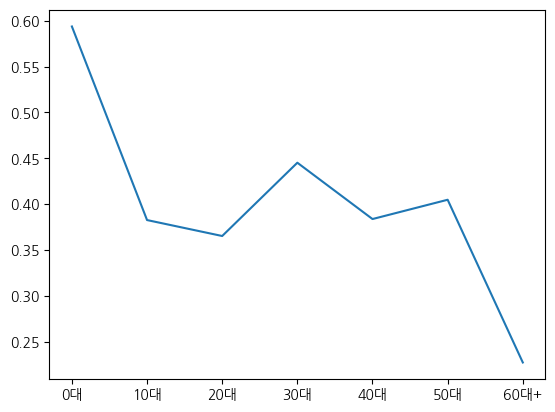

In [7]:
# 그래프로 나타내기
# 연령대 별 생존율

plt.plot(age_survival.index, age_survival.values)
set_korean_font()
plt.show()

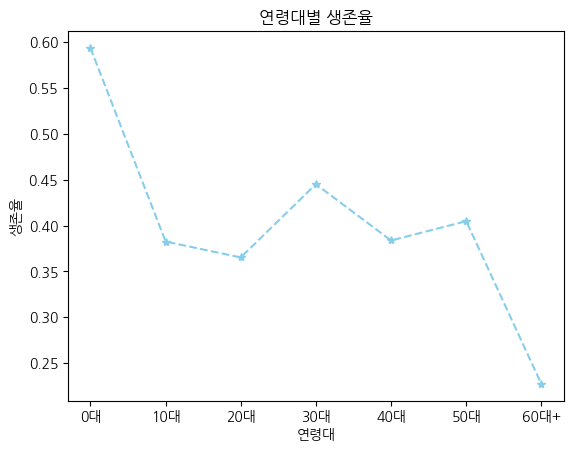

In [8]:
# 연령대 별 생존율
# 옵션 넣기
# marker, color, linestyle
plt.plot(age_survival.index, age_survival.values, marker='*', color='skyblue', linestyle='--')
plt.title('연령대별 생존율')
plt.xlabel('연령대')
plt.ylabel('생존율')
set_korean_font()
plt.show()

### 그래프 옵션

- marker : 'o', 's', '^', 'D', 'x', '+', '*', '.'
- color : 'red', 'blue', 'purple', 'skyblue', 'pink', 'r', 'k', 'y', 'm', 'c'
- linestyle : '-', '--', '-.', ':', 'None'

**여러 항목을 한 그래프에 겹쳐 그리기**

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
male_survival = titanic[titanic["sex"] == "male"].groupby("연령대", observed=True)["survived"].mean()
female_survival = titanic[titanic["sex"] == "female"].groupby("연령대", observed=True)["survived"].mean()

plt.plot(male_survival.index, male_survival.values, marker="o", label="남성")     # label: 범례에 표시될 이름
plt.plot(female_survival.index, female_survival.values, marker="s", label="여성")
plt.title("성별 × 연령대별 생존율")
plt.legend()                       # 범례 표시
plt.show()
# "여성과 아이 먼저"라는 말처럼, 여성의 생존율이 대부분의 연령대에서 훨씬 높게 나타남!
```

</details>

In [9]:
# EDA - 성별에 따른 생존률
male_survival = titanic[titanic["sex"] == "male"].groupby("연령대", observed=True)["survived"].mean()
female_survival = titanic[titanic["sex"] == "female"].groupby("연령대", observed=True)["survived"].mean()



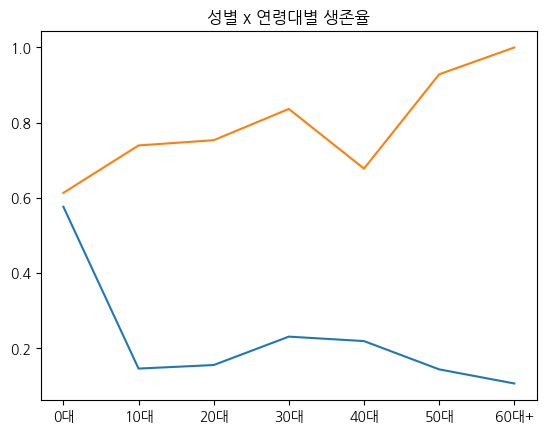

In [10]:
# 2개 그래프 한 번에 그래프 그리기
# 성별, 연령대별 생존율

plt.plot(male_survival.index, male_survival.values)
plt.plot(female_survival.index, female_survival.values)
plt.title("성별 x 연령대별 생존율")
set_korean_font()
plt.show()

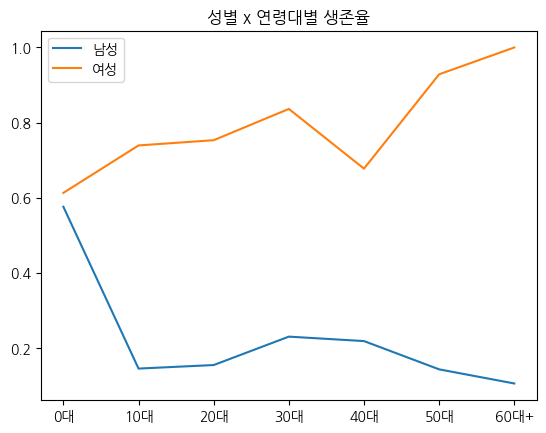

In [11]:
# label 추가하기
# label: 범례에 표시될 이름

plt.plot(male_survival.index, male_survival.values, label='남성')
plt.plot(female_survival.index, female_survival.values, label='여성')

plt.title("성별 x 연령대별 생존율")
plt.legend()    # 지정한 label 범례가 생김

set_korean_font()
plt.show()


### 3) 막대그래프 — `plt.bar()`
- 범주별 값의 크기를 막대 높이로 비교하는 그래프
- 입력은 x와 y (x는 범주, y는 값)
- color, width, edgecolor, label 등으로 막대를 꾸밀 수 있음

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
class_survival = titanic.groupby("pclass")["survived"].mean()

plt.bar(class_survival.index, class_survival.values)
plt.title("좌석 등급별 생존율")
plt.xlabel("좌석 등급 (1=1등석)")
plt.show()
# 1등석일수록 생존율이 높았다는 역사적 사실이 그대로 드러남
```

</details>

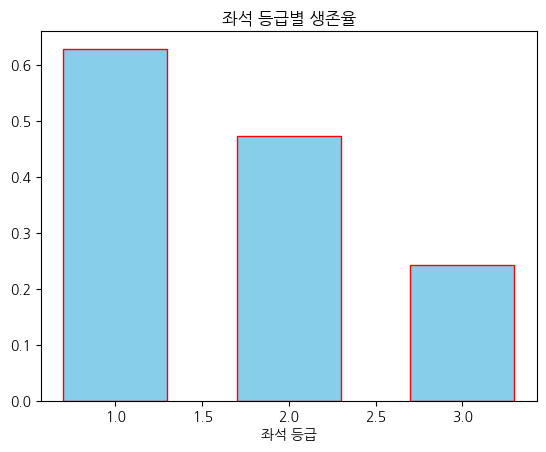

In [12]:
# 좌석 등급별 생존율

# 등급별 생존률 데이터 생성
class_survival = titanic.groupby("pclass")["survived"].mean()

# 그래프 그리기
plt.bar(class_survival.index, class_survival.values, color='skyblue', width=0.6, edgecolor='red')
plt.title('좌석 등급별 생존율')
plt.xlabel('좌석 등급')
set_korean_font()
plt.show()


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 가로 막대그래프
class_fare = titanic.groupby("pclass")["fare"].mean().sort_values()

plt.barh(class_fare.index.astype(str), class_fare.values)
plt.title("좌석 등급별 평균 요금")
plt.show()
```

</details>

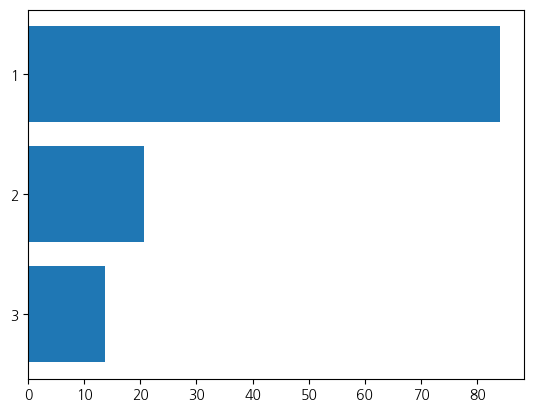

In [13]:
# 좌석 등급별 평균 요금
class_fare = titanic.groupby("pclass")["fare"].mean().sort_values()

# 가로 막대그래프 barh
# .astype(str) : str로 타입 변환
plt.barh(class_fare.index.astype(str), class_fare.values)
set_korean_font()
plt.show()


### 4) 산점도 — `plt.scatter()`

- 두 숫자 데이터의 관계를 점으로 표현하는 그래프
- 입력은 x와 y이며, 각 행이 하나의 점이 됨
- color, s, alpha, marker, label 등으로 점을 꾸밀 수 있음

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
plt.scatter(titanic["age"], titanic["fare"])
plt.xlabel("나이")
plt.ylabel("요금")
plt.title("나이와 요금의 관계")
plt.show()
```

</details>

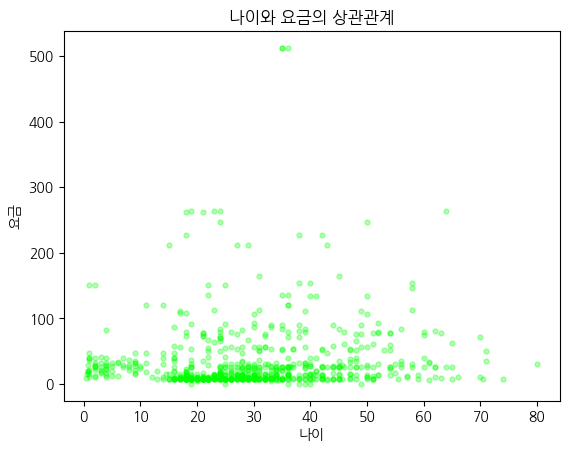

In [14]:
# 나이와 요금과의 관계
# s 점크기, alpha 투명도, marker 점모양

plt.scatter(titanic['age'], titanic['fare'], color='lime', s=50, alpha=0.3,marker='.')
plt.title("나이와 요금의 상관관계")
plt.xlabel('나이')
plt.ylabel('요금')
set_korean_font()
plt.show()

### 5) 히스토그램 — `plt.hist()`
- 숫자 데이터를 일정한 구간으로 나누어 개수를 세는 그래프
- 입력은 x 하나만 (y축은 자동으로 계산)
- bins, color, edgecolor, alpha 등으로 그래프를 꾸밀 수 있음
- bins를 안넣을 경우 자동으로 구간을 나눔

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
plt.hist(titanic["age"].dropna(), bins=8, color="orange", edgecolor="black")
plt.title("승객 나이 분포")
plt.xlabel("나이")
plt.show()
```

</details>

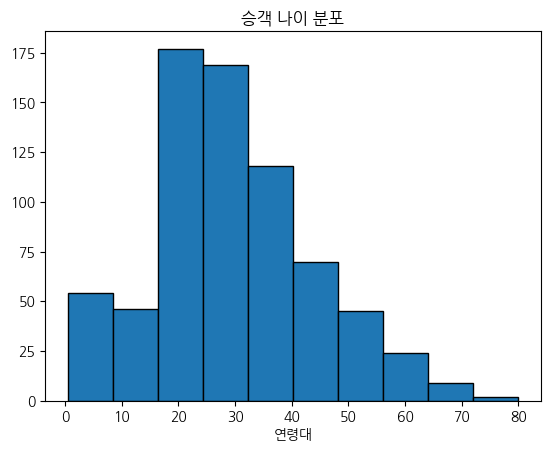

In [15]:
# 히스토그램
# dropna(): 결측치 제거

plt.hist(titanic['age'], edgecolor='black')
plt.title('승객 나이 분포')
plt.xlabel('연령대')
set_korean_font()
plt.show()

### 6) 원그래프 — `plt.pie()`
- 전체에서 각 항목이 차지하는 비율을 원으로 표현하는 그래프
- 입력은 값(x) 하나이며, labels로 항목 이름을 지정
- labels, autopct, colors, startangle 등으로 그래프를 꾸밀 수 있음

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
class_counts = titanic["pclass"].value_counts().sort_index()

plt.pie(class_counts.values, labels=[f"{c}등석" for c in class_counts.index], autopct="%1.1f%%")
plt.title("좌석 등급별 승객 비율")
plt.show()
```

</details>

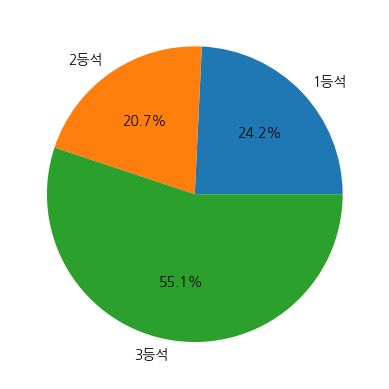

In [16]:
# 등급별 카운트
class_counts = titanic["pclass"].value_counts().sort_index()

# autopct: 자동으로 % 변환 (%1.1%% 소수점 첫째, 1.2 둘째..) (%1 앞은 전체 자리수 (최소폭) 크게 의미 없음)

plt.pie(class_counts.values, labels=[f'{c}등석' for c in class_counts.index], autopct='%1.1f%%')
set_korean_font()
plt.show()


### 7) 그래프 크기와 저장

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
plt.figure(figsize=(8, 4))   # 가로 8, 세로 4 인치 크기로 지정
plt.plot(age_survival.index, age_survival.values, marker="o")
plt.title("연령대별 생존율")
plt.savefig("age_survival.png")   # 이미지 파일로 저장
plt.show()
```

</details>

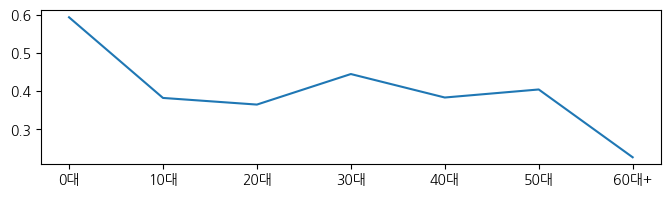

In [17]:
# 코드 입력
# 연령대별 생존율

plt.figure(figsize=(8,2))
plt.plot(age_survival.index, age_survival.values)
set_korean_font()
plt.show()


### 8) 축 범위와 눈금 조절 — `xlim()`/`ylim()`, `xticks()`

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
plt.plot(age_survival.index, age_survival.values, marker="o")
plt.ylim(0, 1)                        # 생존율은 0~1 사이 값이므로 범위를 명확히 지정
plt.title("연령대별 생존율 (y축 범위 지정)")
plt.show()

embark_counts = titanic["embark_town"].value_counts()
plt.bar(embark_counts.index, embark_counts.values)
plt.xticks(rotation=45)               # x축 눈금 라벨을 45도 회전 (글자 겹침 방지)
plt.title("승선 항구별 승객 수")
plt.show()
```

</details>

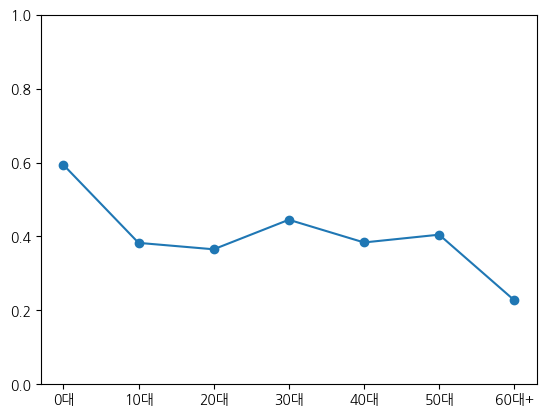

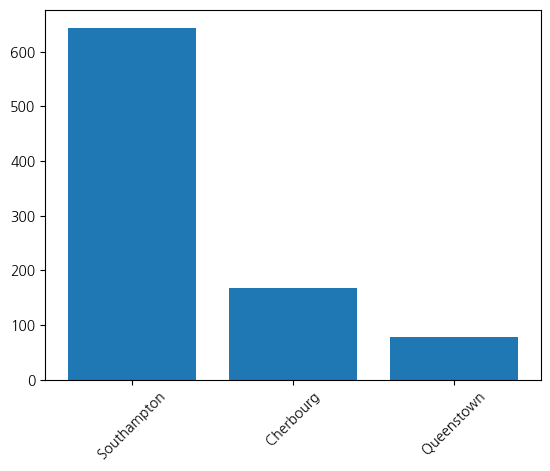

In [18]:
plt.plot(age_survival.index, age_survival.values, marker="o")

# 생존율은 0~1 사이 값이므로 범위를 명확히 지정
plt.ylim(0,1)
set_korean_font()
plt.show()

# 승선 항구별 승객 수
embark_counts = titanic['embark_town'].value_counts()
plt.bar(embark_counts.index, embark_counts.values)

# x축 눈금 라벨을 45도 회전 (글자 겹침 방지)
plt.xticks(rotation=45)
set_korean_font()
plt.show()


> 💡 `ylim()`/`xlim()`으로 축 범위를 조절하면 관심 있는 구간을 확대해서 보여줄 수 있습니다. 다만 막대그래프에서 y축을 0이 아닌 값부터 시작하면 **차이가 실제보다 과장되어 보일 수 있으니** 주의해야 합니다. `xticks(rotation=)`은 항구 이름처럼 x축 라벨이 겹칠 때 필수적으로 사용합니다.

### 9) 격자와 기준선 — `grid()`, `axhline()`/`axvline()`

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
overall_survival = titanic["survived"].mean()

plt.plot(age_survival.index, age_survival.values, marker="o")
plt.grid(True, linestyle="--", alpha=0.5)              # 격자 표시 (점선, 반투명)
plt.axhline(y=overall_survival, color="red", linestyle="--", label=f"전체 평균 생존율 {overall_survival:.2f}")   # 가로 기준선
plt.title("연령대별 생존율과 전체 평균")
plt.legend()
plt.show()
# 어떤 연령대가 평균보다 더 많이/적게 살아남았는지 한눈에 보임
```

</details>

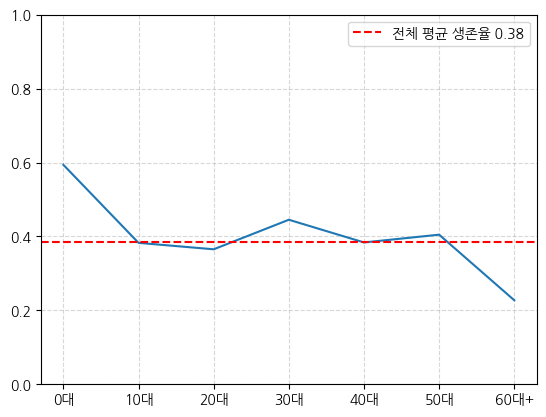

In [19]:
overall_survival = titanic["survived"].mean()

# 격자 그리기
plt.plot(age_survival.index, age_survival.values)
plt.grid(True, linestyle='--', alpha=0.5)

#가로 기준선
plt.axhline(y=overall_survival, color='red', linestyle='--', label=f'전체 평균 생존율 {overall_survival:.2f}')
plt.legend()

set_korean_font()
plt.ylim(0,1)
plt.show()


> 💡 `grid()`는 값을 눈으로 읽기 쉽게 배경 격자를 깔아주고, `axhline()`(가로선)/`axvline()`(세로선)은 목표치·평균·이벤트 시점 같은 **기준선**을 표시할 때 사용합니다. "평균선 대비 얼마나 높은가"처럼 비교 기준을 그래프에 직접 그려 넣으면 전달력이 크게 좋아집니다.

### 10) 그래프에 글자 쓰기 — `text()`, `annotate()`

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
best_group = age_survival.idxmax()     # CH07에서 배운 idxmax() 복습
best_value = age_survival.max()

plt.plot(age_survival.index, age_survival.values, marker="o")
plt.annotate("생존율 최고 연령대!",                                 # 화살표가 있는 주석
             xy=(best_group, best_value),                          # 화살표가 가리키는 지점
             xytext=(best_group, best_value + 0.1),                 # 텍스트가 표시될 위치
             arrowprops=dict(arrowstyle="->", color="red"))
plt.ylim(0, 1)
plt.title("연령대별 생존율 — 최고 구간 표시")
plt.show()
```

</details>

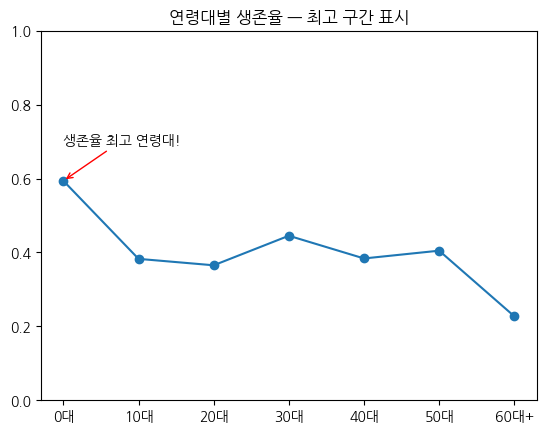

In [21]:
best_group_label = age_survival.idxmax() # '0대', '10대' 등의 레이블
best_value = age_survival.max()

plt.plot(age_survival.index, age_survival.values, marker="o")
plt.annotate("생존율 최고 연령대!",
             xy=(best_group_label, best_value), # 숫자 위치 사용
             xytext=(best_group_label, best_value + 0.1),
             arrowprops=dict(arrowstyle="->", color="red"))
plt.ylim(0, 1)
plt.title("연령대별 생존율 — 최고 구간 표시")
set_korean_font()
plt.show()

> 💡 `text()`는 원하는 좌표에 글자만 쓰고, `annotate()`는 화살표로 특정 지점을 가리키면서 설명을 붙입니다. 보고서용 그래프에서 "이 지점이 중요합니다"를 표시하는 대표적인 방법으로, 발표 자료의 전달력을 높이는 데 매우 유용합니다.

### 11) 서로 다른 방식 비교 — `plot()` vs `bar()`, 언제 무엇을 쓸까?

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# plot(): 값이 "순서가 있는 흐름"을 가질 때 — 추세를 보여주기 좋음 (연령대는 순서가 있음)
plt.plot(age_survival.index, age_survival.values, marker="o")
plt.title("연령대별 생존율 추이 — plot()")
plt.show()
```

</details>

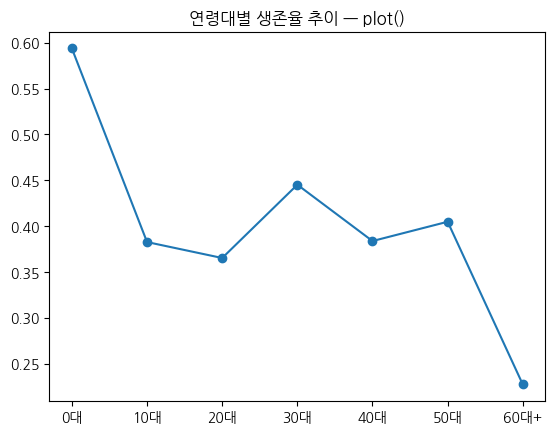

In [22]:
# plot()
# 값이 "순서가 있는 흐름"을 가질 때
# 추세를 보여주기 좋음 (연령대는 순서가 있음)

plt.plot(age_survival.index, age_survival.values, marker="o")
plt.title("연령대별 생존율 추이 — plot()")
set_korean_font()
plt.show()

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# bar(): 서로 "독립적인 범주"를 비교할 때 — 크기 차이를 보여주기 좋음 (좌석 등급은 순서보다 범주 비교)
plt.bar(class_survival.index, class_survival.values)
plt.title("좌석 등급별 생존율 비교 — bar()")
plt.show()
```

</details>

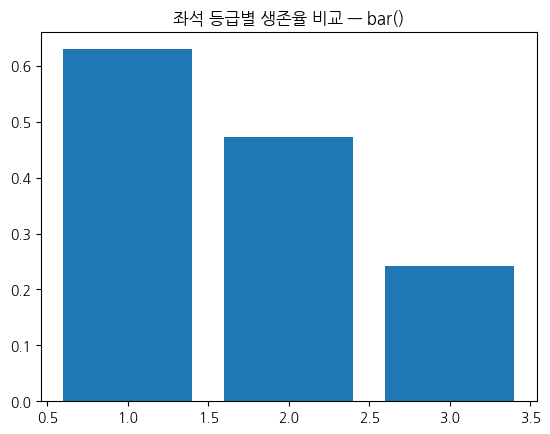

In [23]:
# bar()
# 서로 "독립적인 범주"를 비교할 때
# 크기 차이를 보여주기 좋음 (좌석 등급은 순서보다 범주 비교)
plt.bar(class_survival.index, class_survival.values)
plt.title("좌석 등급별 생존율 비교 — bar()")
set_korean_font()
plt.show()

| 구분 | `plot()` (선 그래프) | `bar()` (막대그래프) |
|---|---|---|
| 데이터 성격 | 순서가 있는 흐름 (연령대, 시간 등) | 독립적인 범주(카테고리)의 비교 |
| 강조하는 것 | 추세, 변화의 방향 | 값의 크기 차이 |
| 예시 | 연령대별 생존율 변화 | 좌석 등급별 생존율, 성별 생존율 |

> 💡 **핵심 요약**: "순서에 따라 어떻게 변하는가"를 보여주려면 선 그래프, "서로 다른 항목끼리 크기를 비교"하려면 막대그래프를 사용하세요.

---

## ⚠️ 자주 하는 실수

> ⚠️ `plt.show()`를 빼먹어서 그래프가 출력되지 않는 경우가 있습니다 (Jupyter에서는 자동 출력되기도 하지만, 명시적으로 쓰는 습관이 안전합니다).

> ⚠️ 여러 그래프를 그릴 때 `plt.legend()`를 빼먹어서 어떤 선이 무엇을 의미하는지 알 수 없는 경우가 흔합니다.

> ⚠️ 한글 폰트가 설정되지 않아 그래프의 한글 제목/레이블이 네모(□)로 깨져 보이는 경우가 있습니다 (환경별 한글 폰트 설정 필요).

> ⚠️ x축 라벨이 길거나 많아서 서로 겹쳐 보이는데 그대로 두는 경우가 있습니다 — `plt.xticks(rotation=45)`로 회전시키면 해결됩니다.

> ⚠️ 나이(`age`)처럼 결측치가 있는 컬럼을 히스토그램 등에 바로 넣으면 에러가 날 수 있습니다 — `dropna()`로 결측치를 먼저 제외해야 합니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 한글 폰트 깨짐 방지 예시 (환경에 따라 폰트 이름은 다를 수 있음)
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
# plt.rcParams["font.family"] = "AppleGothic"   # Mac
plt.rcParams["axes.unicode_minus"] = False        # 마이너스 기호 깨짐 방지
```

</details>

In [24]:
# 코드 입력

# 한글 폰트 깨짐 방지 예시 (환경에 따라 폰트 이름은 다를 수 있음)
# plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
# # plt.rcParams["font.family"] = "AppleGothic"   # Mac
# plt.rcParams["axes.unicode_minus"] = False        # 마이너스 기호 깨짐 방지

---

## 🚀 실무에서는?

> 🚀 데이터 분석 보고서, 대시보드의 기본 그래프는 대부분 Matplotlib(또는 이를 기반으로 한 Seaborn)으로 만들어집니다. 빠르게 데이터의 개요를 시각적으로 확인할 때 가장 먼저 사용하는 도구입니다.

---

## 🧩 Check Point

**Q1.** 순서가 있는 흐름(예: 연령대별 변화)을 보여주기에 가장 적합한 그래프는? ① bar() ② plot() ③ pie() ④ hist()
<details><summary>정답</summary>② plot()</details>

**Q2.** 범례를 표시하기 위해 각 plot에 지정해야 하는 옵션은? ① title ② label ③ color ④ marker
<details><summary>정답</summary>② label (그 후 legend()로 표시)</details>

**Q3.** 그래프에 "전체 평균 생존율"처럼 가로 기준선을 그리는 함수는? ① grid() ② axhline() ③ text() ④ xticks()
<details><summary>정답</summary>② axhline() (세로선은 axvline())</details>

**Q4.** 화살표로 특정 지점을 가리키며 설명을 붙이는 함수는? ① text() ② annotate() ③ legend() ④ title()
<details><summary>정답</summary>② annotate() — text()는 화살표 없이 글자만 씁니다</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. 난이도가 단계적으로 올라갑니다.

In [25]:
# TODO 1 (선 그래프): 연령대별 생존율(age_survival)을 선 그래프로 그리세요 (제목 포함)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
plt.plot(age_survival.index, age_survival.values, marker="o")
plt.title("연령대별 생존율")
plt.ylim(0, 1)
plt.show()
```

</details>

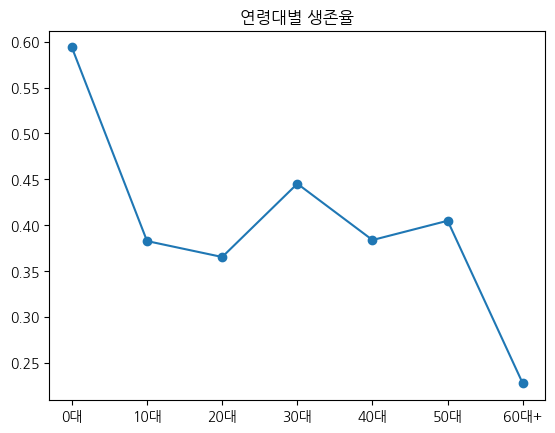

In [26]:
# 코드 입력

plt.plot(age_survival.index, age_survival.values, marker="o")
plt.title("연령대별 생존율")
set_korean_font()
plt.show()

In [27]:
# TODO 2 (막대그래프): 성별(sex)에 따른 생존율을 막대그래프로 그리세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
sex_survival = titanic.groupby("sex")["survived"].mean()
plt.bar(sex_survival.index, sex_survival.values, color=["tomato", "skyblue"])
plt.title("성별 생존율")
plt.show()
```

</details>

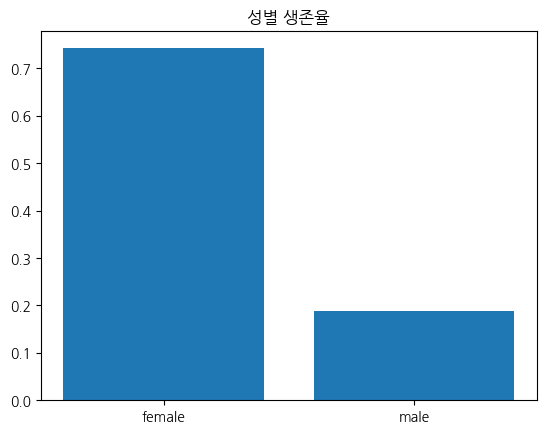

In [28]:
# 코드 입력

sex_survival = titanic.groupby('sex')['survived'].mean()
plt.bar(sex_survival.index, sex_survival.values)
plt.title('성별 생존율')
set_korean_font()
plt.show()


In [29]:
# TODO 3 (산점도): 나이(age)와 형제자매/배우자 수(sibsp) 사이의 관계를 산점도로 그려 확인하세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
plt.scatter(titanic["age"], titanic["sibsp"])
plt.xlabel("나이")
plt.ylabel("형제자매/배우자 수")
plt.title("나이와 동승 가족 수의 관계")
plt.show()
```

</details>

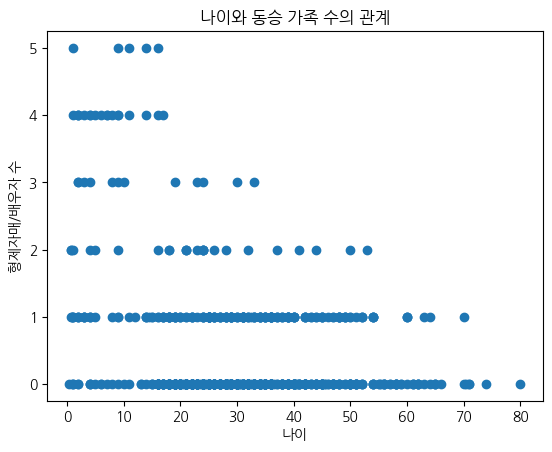

In [30]:
# 코드 입력

plt.scatter(titanic['age'], titanic['sibsp'])
plt.xlabel('나이')
plt.ylabel('형제자매/배우자 수')
plt.title('나이와 동승 가족 수의 관계')
set_korean_font()
plt.show()

In [31]:
# TODO 4 (여러 선 겹치기): 1등석과 3등석 승객의 연령대별 생존율을 한 그래프에 범례와 함께 그리세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
first_survival = titanic[titanic["pclass"] == 1].groupby("연령대", observed=True)["survived"].mean()
third_survival = titanic[titanic["pclass"] == 3].groupby("연령대", observed=True)["survived"].mean()

plt.plot(first_survival.index, first_survival.values, marker="o", label="1등석")
plt.plot(third_survival.index, third_survival.values, marker="s", label="3등석")
plt.title("좌석 등급별 연령대 생존율 비교")
plt.legend()
plt.show()
```

</details>

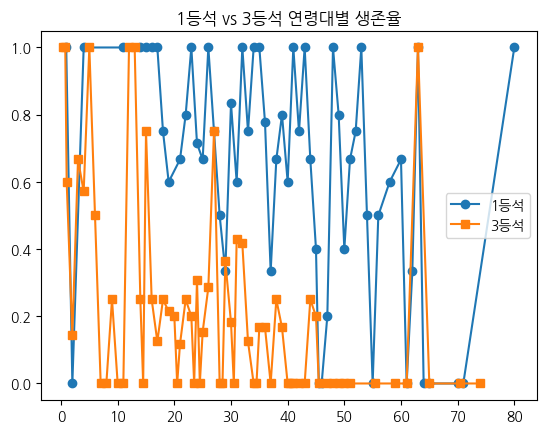

In [32]:
# 코드 입력

first_survival = titanic[titanic['pclass'] == 1].groupby('age')['survived'].mean()
third_survival = titanic[titanic['pclass'] == 3].groupby('age')['survived'].mean()

plt.plot(first_survival.index, first_survival.values, marker='o', label='1등석')
plt.plot(third_survival.index, third_survival.values, marker='s', label='3등석')
plt.title('1등석 vs 3등석 연령대별 생존율')
plt.legend()
set_korean_font()
plt.show()


In [33]:
# TODO 5 (히스토그램): 요금(fare) 데이터의 분포를 히스토그램으로 확인하세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
plt.hist(titanic["fare"], bins=10, color="skyblue", edgecolor="black")
plt.title("요금 분포")
plt.show()
```

</details>

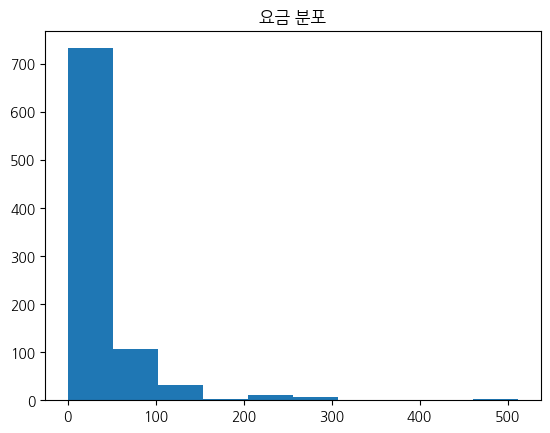

In [34]:
# 코드 입력

plt.hist(titanic['fare'])
plt.title('요금 분포')
set_korean_font()
plt.show()

In [35]:
# TODO 6 (기준선): 연령대별 생존율 선 그래프에 전체 평균 생존율을 빨간 점선 기준선으로 표시하세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
overall = titanic["survived"].mean()
plt.plot(age_survival.index, age_survival.values, marker="o")
plt.axhline(y=overall, color="red", linestyle="--", label=f"평균 {overall:.2f}")
plt.legend()
plt.show()
```

</details>

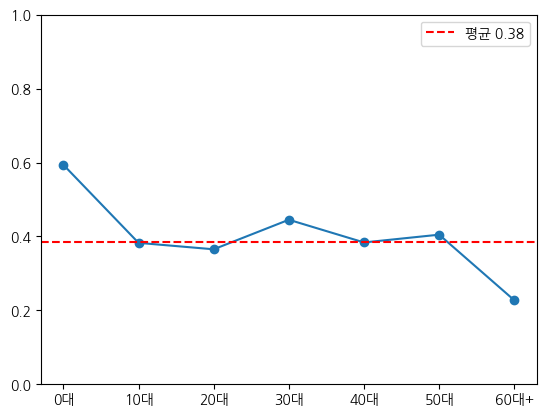

In [36]:
# 코드 입력
survival_mean = titanic['survived'].mean()
plt.plot(age_survival.index, age_survival.values, marker='o')
plt.axhline(y=survival_mean, color='red', linestyle='--', label=f'평균 {survival_mean:.2f}')

plt.ylim(0, 1) # Y축 범위를 0에서 1로 설정하여 생존율을 명확하게 표시
plt.legend()
plt.show()

In [37]:
# TODO 7 (주석): 생존율이 가장 낮은 연령대를 annotate()로 화살표와 함께 표시하세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
worst_group = age_survival.idxmin()
worst_value = age_survival.min()
plt.plot(age_survival.index, age_survival.values, marker="o")
plt.annotate("생존율 최저", xy=(worst_group, worst_value),
             xytext=(worst_group, worst_value + 0.15),
             arrowprops=dict(arrowstyle="->", color="blue"))
plt.ylim(0, 1)
plt.show()
```

</details>

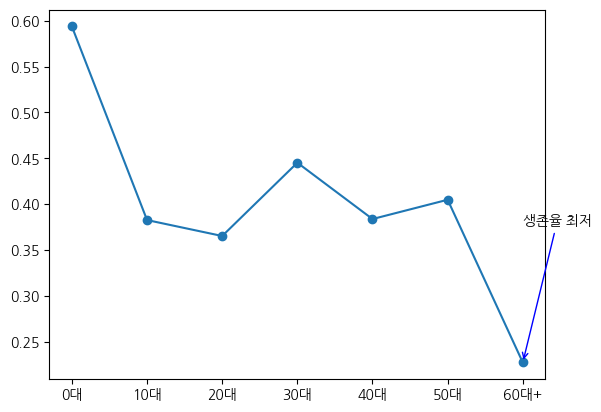

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# titanic DataFrame을 다시 로드하고 '연령대' 컬럼을 생성
titanic = pd.read_csv("titanic.csv")
titanic["연령대"] = pd.cut(titanic["age"], bins=[0, 10, 20, 30, 40, 50, 60, 80],
                          labels=["0대", "10대", "20대", "30대", "40대", "50대", "60대+"])

# 연령대별 생존율
age_survival_series = titanic.groupby("연령대", observed=True)["survived"].mean()

lowest_group = age_survival_series.idxmin()
lowest_value = age_survival_series.min()

plt.plot(age_survival_series.index, age_survival_series.values, marker='o')

plt.annotate("생존율 최저",                                 # 화살표가 있는 주석
             xy=(lowest_group, lowest_value),                          # 화살표가 가리키는 지점
             xytext=(lowest_group, lowest_value + 0.15),                 # 텍스트가 표시될 위치
             arrowprops=dict(arrowstyle="->", color="blue"))
set_korean_font()
plt.show()


---

## 📝 실습 과제

In [39]:
# 과제 1: 연령대별 생존율(age_survival) 선 그래프에 제목과 x축("연령대"), y축("생존율") 레이블을 추가하세요

In [40]:
# 과제 2: 승선 항구(embark_town)별 평균 요금을 막대그래프로 그리고, "embark_fare.png" 파일로 저장하세요

In [41]:
# 과제 3: 좌석 등급별 생존율 막대그래프에 전체 평균 생존율 기준선(axhline)을 표시하고,
#         가장 생존율이 높은 등급에 주석(annotate)을 다세요

**예시 정답**

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
plt.plot(age_survival.index, age_survival.values, marker="o")
plt.title("연령대별 생존율")
plt.xlabel("연령대")
plt.ylabel("생존율")
plt.ylim(0, 1)
plt.show()
```

</details>

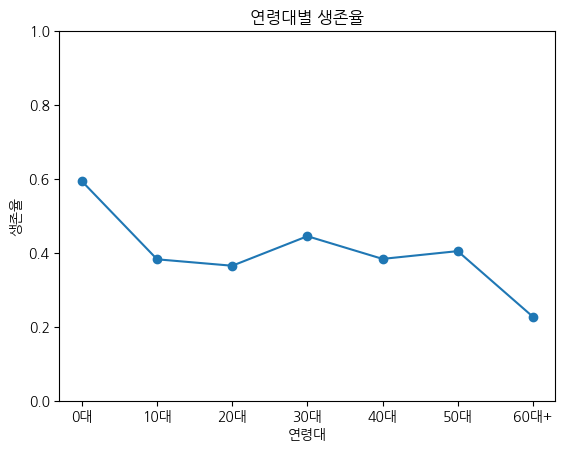

In [42]:
# 과제 1 예시 정답

plt.plot(age_survival.index, age_survival.values, marker='o')
plt.title('연령대별 생존율')
plt.xlabel('연령대')
plt.ylabel('생존율')
plt.ylim(0, 1)
set_korean_font()
plt.show()


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
embark_fare = titanic.groupby("embark_town")["fare"].mean()
plt.bar(embark_fare.index, embark_fare.values, color="mediumseagreen")
plt.title("승선 항구별 평균 요금")
plt.xticks(rotation=45)
plt.savefig("embark_fare.png")
plt.show()
```

</details>

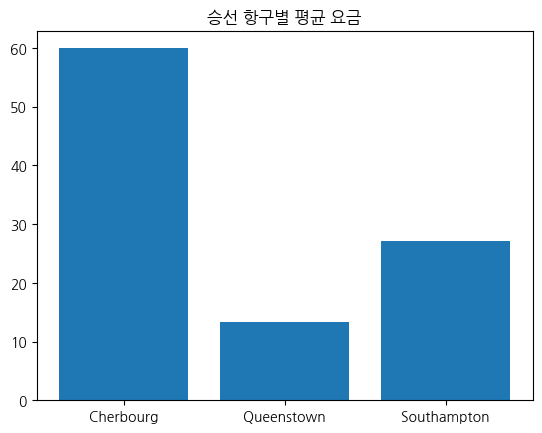

In [43]:
# 과제 2 예시 정답

embark_fare = titanic.groupby('embark_town')['fare'].mean()
plt.bar(embark_fare.index, embark_fare.values)
plt.title('승선 항구별 평균 요금')
plt.savefig('embark_fare.png')
set_korean_font()
plt.show()


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 3 예시 정답
class_survival = titanic.groupby("pclass")["survived"].mean()
overall = titanic["survived"].mean()
best_class = class_survival.idxmax()

plt.bar(class_survival.index, class_survival.values)
plt.axhline(y=overall, color="red", linestyle="--", label=f"평균 {overall:.2f}")
plt.annotate("최고 생존율", xy=(best_class, class_survival.max()),
             xytext=(best_class, class_survival.max() + 0.1),
             arrowprops=dict(arrowstyle="->", color="red"))
plt.ylim(0, 1)
plt.legend()
plt.show()
```

</details>

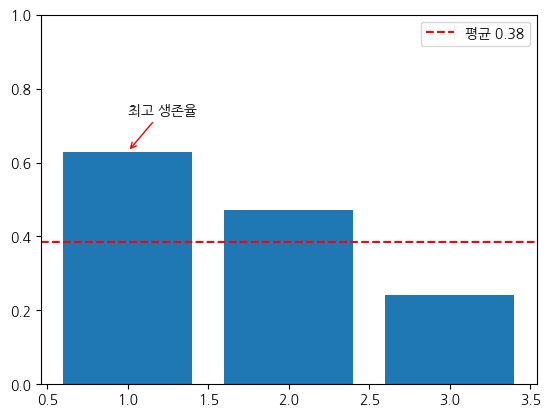

In [44]:
# 과제 3 예시 정답

class_survival = titanic.groupby('pclass')['survived'].mean()
overall = titanic['survived'].mean()
best_class = class_survival.idxmax()

plt.bar(class_survival.index, class_survival.values)
plt.axhline(y=overall, color='red', linestyle='--', label=f'평균 {overall:.2f}')
plt.annotate('최고 생존율', xy=(best_class, class_survival.max()), xytext=(best_class, class_survival.max() + 0.1), arrowprops=dict(arrowstyle='->', color='red'))
plt.ylim(0, 1)
plt.legend()
set_korean_font()
plt.show()


---

## 📌 핵심 정리

- `plt.plot()`: 선 그래프(추세) / `plt.bar()`, `plt.barh()`: 막대그래프(범주 비교)
- `plt.scatter()`: 산점도(관계) / `plt.hist()`: 히스토그램(분포) / `plt.pie()`: 원그래프(비율)
- `title()`, `xlabel()`, `ylabel()`, `legend()`로 그래프에 정보를 추가
- `xlim()`/`ylim()`: 축 범위 지정, `xticks(rotation=)`: 눈금 라벨 회전 (겹침 방지)
- `grid()`: 배경 격자, `axhline()`/`axvline()`: 가로/세로 기준선 (목표·평균 표시)
- `text()`: 좌표에 글자, `annotate()`: 화살표가 있는 주석 (강조 지점 표시)
- `figsize`로 크기 조절, `savefig()`로 파일 저장
- 추세 파악은 선 그래프, 범주 간 크기 비교는 막대그래프

---

---

# 📘 CH08-02. Seaborn 활용

## 🤔 먼저 생각해보기

> **좌석 등급별 요금 분포를 그릴 때, 평균만이 아니라 "값들이 얼마나 퍼져 있는지"까지 한 번에 보여줄 수는 없을까요?**

Matplotlib이 "그리는 방법"을 하나하나 지정해야 한다면, **Seaborn**은 DataFrame과 컬럼명만 알려주면 통계적으로 의미 있는 그래프를 훨씬 간결하게 그려줍니다. 타이타닉 데이터는 Seaborn 공식 예제로도 가장 자주 쓰이는 데이터셋입니다.

---

## 📖 핵심 개념

### 0) 실습 데이터 준비

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import seaborn as sns   # 관례적으로 sns라는 별칭 사용
import pandas as pd

titanic = pd.read_csv("titanic.csv")
print(titanic[["survived", "pclass", "sex", "age", "fare", "embark_town"]].head())
```

</details>

In [45]:
# 코드 입력

import seaborn as sns   # 관례적으로 sns라는 별칭 사용
import pandas as pd



### 1) Seaborn이란? — Matplotlib을 기반으로 한 통계 시각화 도구

- Pandas의 DataFrame을 그대로 넘겨서 컬럼명만 지정하면 그래프가 완성됨
- 평균, 분포 등 통계 계산을 자동으로 처리해줌

### 2) `barplot()` — 그룹별 평균을 자동으로 계산해서 막대로
- 범주별 평균값을 막대로 비교하는 그래프
- 입력은 data, x, y가 필수

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
sns.barplot(data=titanic, x="pclass", y="survived")
plt.title("좌석 등급별 생존율")
plt.show()
```

</details>

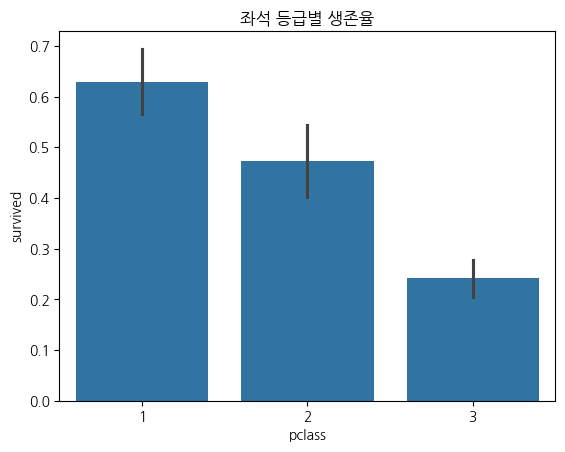

In [46]:
# 오차막대: (막대끝 까만선) 막대의 평균값 주변의 오차를 나타내는 선

# plt.bar() matplotlib
# x=[1,2,3]
# y=[10,20,30]
# plt.plot(x,y)

sns.barplot(data=titanic, x='pclass', y='survived')
plt.title("좌석 등급별 생존율")
set_korean_font()
plt.show()

### 3) `lineplot()` — 추세선

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
age_survival = titanic.groupby("age")["survived"].mean().reset_index()

sns.lineplot(data=age_survival, x="age", y="survived")
plt.title("나이에 따른 생존율 변화")
plt.show()
```

</details>

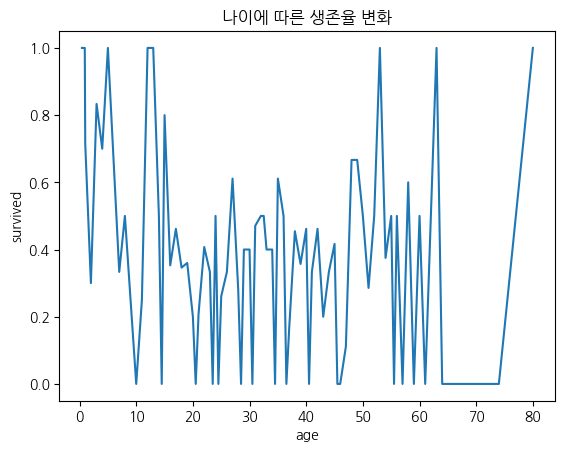

In [47]:
# 연령별 생존율
# 데이터 만들기
age_survival = titanic.groupby('age')['survived'].mean().reset_index()

# 그래프 그리기
sns.lineplot(data=age_survival, x='age', y='survived')
plt.title("나이에 따른 생존율 변화")
set_korean_font()
plt.show()

### 4) `scatterplot()` — 두 변수 사이의 관계 (hue로 카테고리 구분 추가)

- 두 숫자 데이터의 관계를 점으로 표현하는 그래프
- 입력은 data, x, y가 필수
- hue, size, style로 추가 정보를 함께 표현할 수 있음

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
sns.scatterplot(data=titanic, x="age", y="fare", hue="survived", s=60)   # hue: 생존 여부별로 색상을 다르게
plt.title("나이-요금 관계 (생존 여부 색상 구분)")
plt.show()
```

</details>

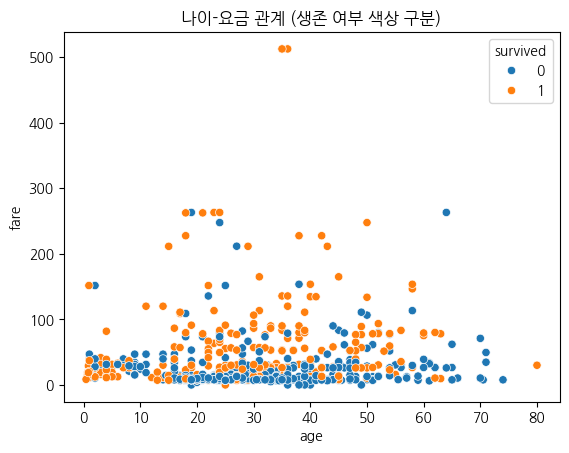

In [48]:
# hue: 생존 여부별로 색상을 다르게
# Seaborn은 DataFrame의 컬럼명을 자동으로 축 이름으로 사용

sns.scatterplot(data=titanic, x='age', y='fare', hue='survived')
plt.title('나이-요금 관계 (생존 여부 색상 구분)')
set_korean_font()
plt.show()

### 5) `histplot()` — 분포 확인

- 숫자 데이터의 분포를 구간별로 나타내는 그래프
- 입력은 data와 x가 필수
- bins, kde, hue로 분포를 자세히 확인할 수 있음



<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
sns.histplot(data=titanic, x="age", bins=20, kde=True)   # kde=True: 분포 곡선도 함께 표시
plt.title("승객 나이 분포")
plt.show()
```

</details>

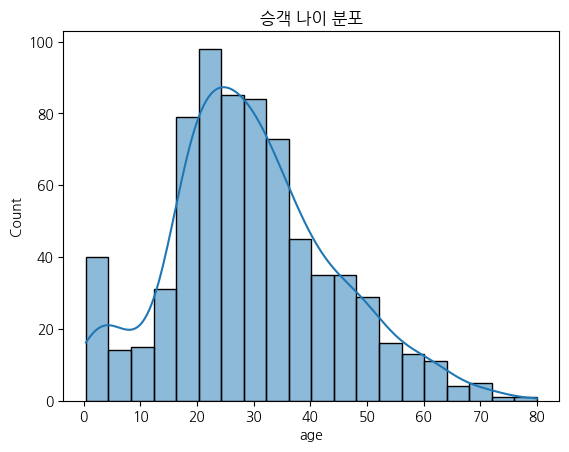

In [49]:
# kde=True: 분포 곡선도 함께 표시

sns.histplot(data=titanic, x='age', bins=20, kde=True)

plt.title("승객 나이 분포")
set_korean_font()
plt.show()

### 6) `boxplot()` — 그룹별 분포·이상치를 한눈에


- 데이터의 분포와 이상치를 한눈에 보여주는 그래프
- 입력은 data와 x 또는 y가 필수
- hue를 사용하면 그룹별 분포를 비교할 수 있음

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
sns.boxplot(data=titanic, x="pclass", y="fare")
plt.title("좌석 등급별 요금 분포 (박스플롯)")
plt.show()
```

</details>

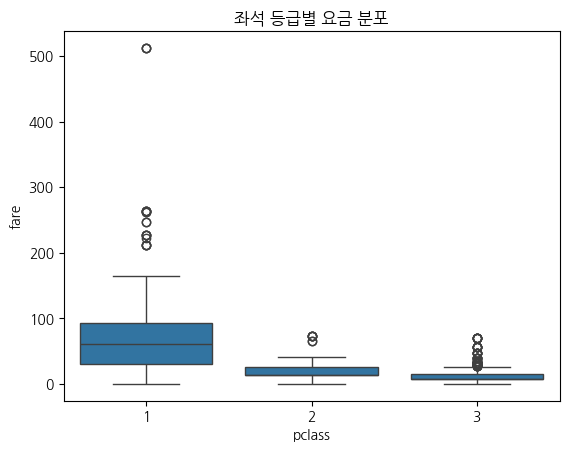

In [50]:
# 코드 입력
# 좌석 등급별 요금 분포
# titanic
sns.boxplot(data=titanic, x='pclass', y='fare')
plt.title("좌석 등급별 요금 분포")
set_korean_font()
plt.show()

> 💡 박스플롯의 상자는 중간 50% 데이터의 범위(사분위수)를, 상자 밖 점은 이상치(outlier)를 보여줍니다. 평균만 보는 막대그래프보다 데이터가 얼마나 퍼져 있는지, 이상치가 있는지까지 함께 파악할 수 있습니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
numeric_df = titanic[["survived", "age", "fare", "sibsp", "parch"]]
correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm")   # annot=True: 각 칸에 숫자 값 표시
plt.title("생존·나이·요금 등 변수 간 상관관계")
plt.show()
```

</details>

### 7) `heatmap()` — 두 변수의 상관관계


- 숫자 데이터를 색상으로 표현하는 그래프
- 입력은 2차원 데이터(행렬 또는 상관계수)가 필수
- annot, cmap 옵션으로 값을 표시하거나 색상을 변경할 수 있음

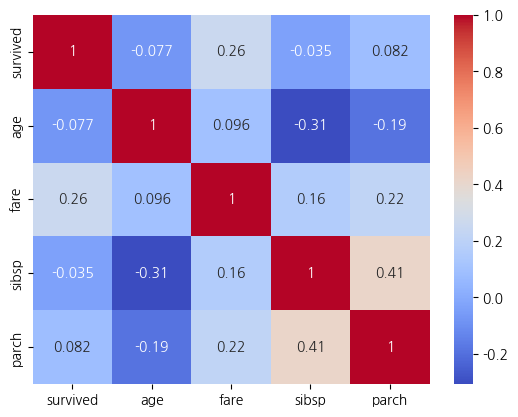

In [51]:
# SibSp = Siblings + Spouses → 함께 탑승한 형제자매 + 배우자 수
# Parch = Parents + Children → 함께 탑승한 부모 + 자녀 수
# .corr() = 상관계수 확인

numeric_df = titanic[['survived', 'age', 'fare', 'sibsp', 'parch']]
# numeric_df
correlation = numeric_df.corr()

# # annot=True: 각 칸에 숫자 값 표시
# sns.heatmap(correlation)
sns.heatmap(data = correlation, annot=True, cmap='coolwarm')
set_korean_font()
plt.show()

### 8) `countplot()` — 범주별 "개수"를 자동으로 세서 막대로

- 범주별 데이터 개수(빈도)를 막대로 나타내는 그래프
- 입력은 data와 x(또는 y)만 사용
- hue, palette 옵션으로 그룹별 비교가 가능

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
sns.countplot(data=titanic, x="pclass")
plt.title("좌석 등급별 승객 수")
plt.show()
```

</details>

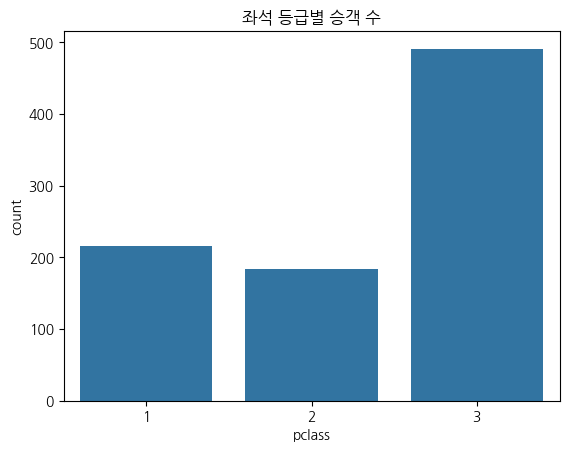

In [52]:
# 코드 입력

sns.countplot(data=titanic, x='pclass')
plt.title("좌석 등급별 승객 수")
set_korean_font()
plt.show()

> 💡 `barplot()`은 y에 지정한 수치 컬럼의 **평균**을 보여주는 반면, `countplot()`은 y 없이 **행의 개수**를 자동으로 세서 보여줍니다. CH07에서 배운 `value_counts()`의 결과를 그래프로 그린 것과 같으며, 범주형 데이터의 빈도 확인에 가장 간단한 방법입니다.

### 9) `violinplot()` — 분포의 "모양"까지 보여주는 boxplot의 확장

- 데이터의 분포 모양과 밀도를 함께 보여주는 그래프
- 입력은 data와 x 또는 y가 필수
- hue, split 옵션으로 그룹별 분포를 비교할 수 있음



<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
sns.violinplot(data=titanic, x="survived", y="age")
plt.title("생존 여부별 나이 분포 (바이올린플롯)")
plt.xlabel("생존 여부 (0=사망, 1=생존)")
plt.show()
```

</details>

In [53]:
# 코드 입력





> 💡 `boxplot()`이 사분위수·이상치를 요약해서 보여준다면, `violinplot()`은 여기에 **분포의 밀도 곡선(어느 값 근처에 데이터가 몰려 있는지)**까지 좌우 대칭의 바이올린 모양으로 함께 보여줍니다. 예를 들어 생존자 중 어린이 비중이 더 큰지 등을 모양으로 바로 확인할 수 있습니다.

### 10) `pairplot()` — 여러 수치형 변수의 관계를 한 번에

- 숫자형 변수들 간의 관계를 한 번에 보여주는 그래프
- 각 변수끼리는 산점도, 자기 자신은 히스토그램(또는 KDE)으로 표시
- hue를 사용하면 그룹별 색상을 구분하여 비교할 수 있음

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
sns.pairplot(titanic[["age", "fare", "survived"]].dropna())
plt.show()

sns.pairplot(titanic[["age", "fare", "sibsp", "survived"]].dropna(), hue="survived")
plt.show()
```

</details>

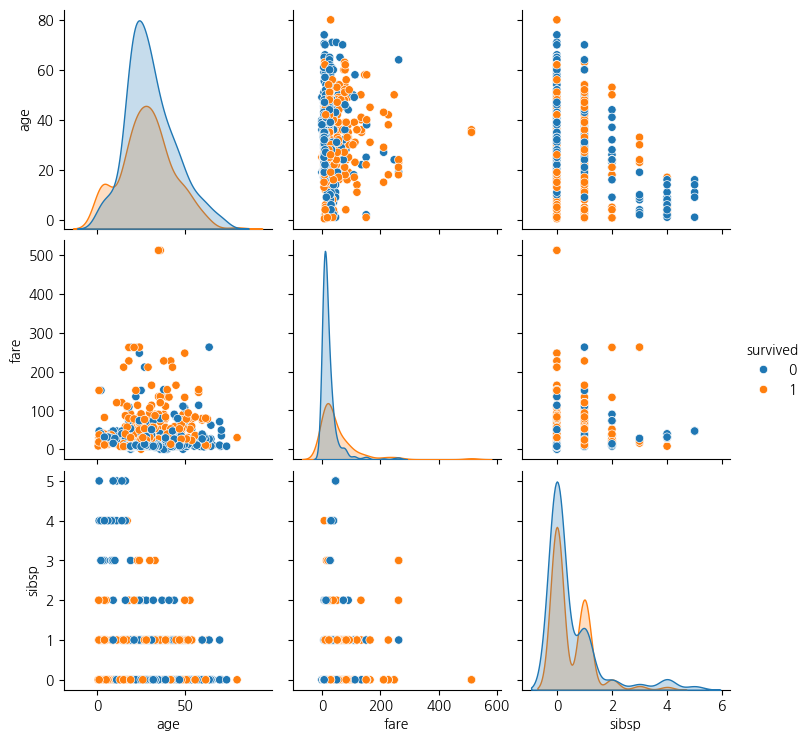

In [54]:
# 코드 입력
# sns.pairplot(titanic[['age', 'fare', 'survived']].dropna())
# plt.show()

sns.pairplot(titanic[['age', 'fare', 'sibsp', 'survived']].dropna(), hue='survived')
set_korean_font()
plt.show()

> 💡 `pairplot()`은 지정한 수치형 컬럼들의 **모든 쌍 조합**에 대해 산점도를, 대각선에는 각 변수의 분포를 한 번에 그려줍니다. EDA 초반에 "어떤 변수끼리 관계가 있어 보이는지" 전체 그림을 빠르게 훑을 때 유용하며, `heatmap()`이 상관계수를 숫자로 요약한다면 `pairplot()`은 실제 데이터의 흩어진 모양을 직접 보여줍니다.

### 11) 서로 다른 방식 비교 — Matplotlib vs Seaborn

같은 그래프(좌석 등급별 생존율 막대그래프)를 두 가지 방식으로 그려 비교해봅니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 방법 A: Matplotlib — 그룹별 평균을 직접 계산한 뒤 그려야 함
import matplotlib.pyplot as plt
grouped = titanic.groupby("pclass")["survived"].mean()
plt.bar(grouped.index, grouped.values)
plt.title("좌석 등급별 생존율 (Matplotlib)")
plt.show()
```

</details>

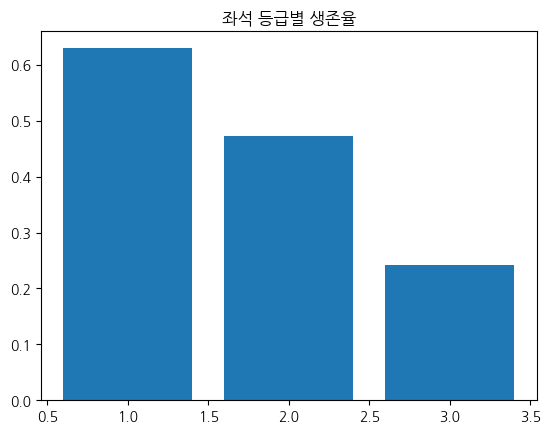

In [55]:
# 방법 A: Matplotlib — 그룹별 평균을 직접 계산한 뒤 그려야 함

grouped = titanic.groupby('pclass')['survived'].mean()

plt.bar(grouped.index, grouped.values)
plt.title("좌석 등급별 생존율")
set_korean_font()
plt.show()

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 방법 B: Seaborn — 원본 DataFrame과 컬럼명만 지정하면 평균 계산까지 자동으로
sns.barplot(data=titanic, x="pclass", y="survived")
plt.title("좌석 등급별 생존율 (Seaborn)")
plt.show()
```

</details>

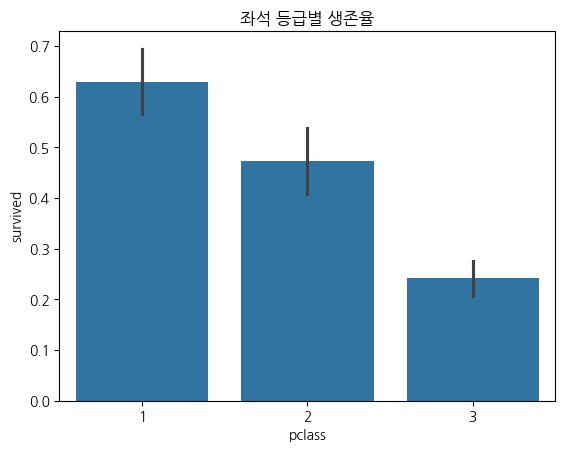

In [56]:
# 방법 B: Seaborn — 원본 DataFrame과 컬럼명만 지정하면 평균 계산까지 자동으로

sns.barplot(data=titanic, x='pclass', y='survived')
plt.title("좌석 등급별 생존율")
set_korean_font()
plt.show()

| 구분 | Matplotlib | Seaborn |
|---|---|---|
| 데이터 입력 | 계산된 값(리스트/배열)을 직접 전달 | DataFrame + 컬럼명 |
| 통계 계산 | 직접 `groupby()` 등으로 계산 필요 | 자동으로 평균·분포 계산 |
| 스타일 | 기본 스타일이 단순함 | 통계 그래프에 최적화된 기본 스타일 |
| 커스터마이징 | 세밀한 제어가 쉬움 | Matplotlib 함수와 함께 사용해 보완 |

> 💡 **핵심 요약**: 빠르게 통계적 인사이트를 확인하고 싶다면 Seaborn, 세밀한 커스터마이징이 필요하다면 Matplotlib(또는 둘을 함께 사용)을 선택하세요.

---

## ⚠️ 자주 하는 실수

> ⚠️ `heatmap()`에 문자열 컬럼이 섞인 DataFrame을 그대로 넣으면 에러가 납니다 — 반드시 숫자형 컬럼만 골라서(`corr()` 결과) 전달해야 합니다.

> ⚠️ 개수를 그리고 싶은데 `barplot()`을 쓰거나(평균이 그려짐), 평균을 그리고 싶은데 `countplot()`을 쓰는 혼동이 흔합니다 — 평균은 barplot, 빈도는 countplot입니다.

> ⚠️ `pairplot()`에 결측치(나이 등)가 섞인 컬럼을 그대로 넣으면 경고가 발생하거나 일부 점이 제외될 수 있습니다 — `dropna()`로 먼저 정리하는 것이 안전합니다.

---

## 🧩 Check Point

**Q1.** 그룹별 평균을 자동으로 계산해서 막대그래프로 보여주는 함수는? ① countplot() ② barplot() ③ histplot() ④ boxplot()
<details><summary>정답</summary>② barplot()</details>

**Q2.** `scatterplot()`에서 카테고리별로 색을 다르게 구분하는 옵션은? ① color ② hue ③ style ④ label
<details><summary>정답</summary>② hue</details>

**Q3.** 좌석 등급별 "승객 수"를 y 지정 없이 자동으로 세서 막대로 그리는 함수는? ① barplot() ② countplot() ③ histplot() ④ boxplot()
<details><summary>정답</summary>② countplot() — barplot()은 y로 지정한 수치의 평균을 그립니다</details>

**Q4.** 여러 수치형 변수의 쌍 조합별 산점도와 분포를 한 번에 그려주는 함수는? ① heatmap() ② violinplot() ③ pairplot() ④ lineplot()
<details><summary>정답</summary>③ pairplot()</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. 난이도가 단계적으로 올라갑니다.

In [57]:
# TODO 1 (barplot): 성별(sex)에 따른 평균 생존율을 barplot으로 그리세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
sns.barplot(data=titanic, x="sex", y="survived")
plt.title("성별 생존율")
plt.show()
```

</details>

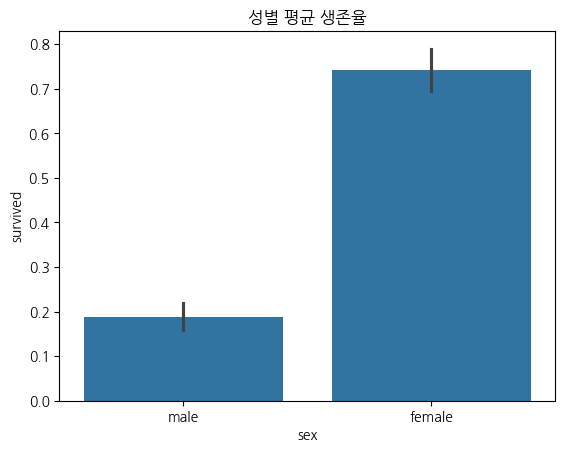

In [58]:
# 코드 입력

sns.barplot(data=titanic, x='sex', y='survived')
plt.title("성별 평균 생존율")
set_korean_font()
plt.show()


In [59]:
# TODO 2 (boxplot): 좌석 등급별 나이 분포를 boxplot으로 그리세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
sns.boxplot(data=titanic, x="pclass", y="age")
plt.show()
```

</details>

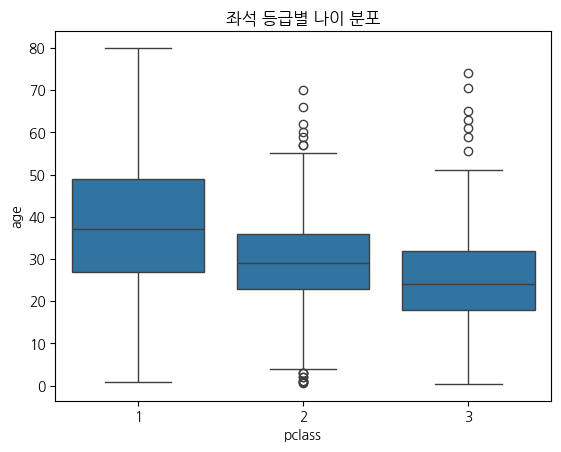

In [60]:
# 코드 입력

sns.boxplot(data=titanic, x='pclass', y='age')
plt.title("좌석 등급별 나이 분포")
set_korean_font()
plt.show()


In [61]:
# TODO 3 (scatterplot+hue): 나이와 요금의 관계를 좌석 등급별로 색을 구분해서 그리세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
sns.scatterplot(data=titanic, x="age", y="fare", hue="pclass")
plt.show()
```

</details>

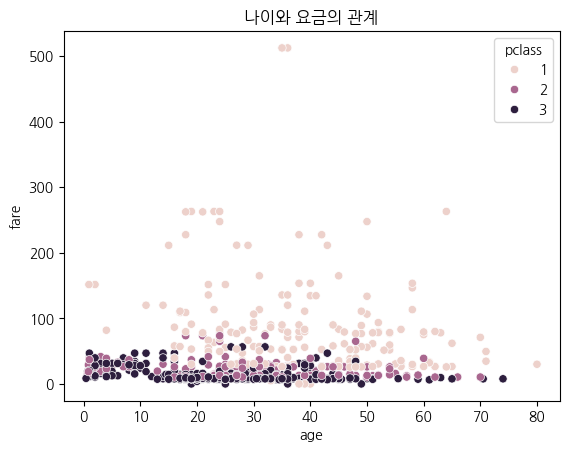

In [62]:
# 코드 입력

sns.scatterplot(data=titanic, x='age', y='fare', hue='pclass')
plt.title("나이와 요금의 관계")
set_korean_font()
plt.show()


In [63]:
# TODO 4 (heatmap): 생존, 나이, 요금, 형제자매수 간의 상관관계를 히트맵으로 그리세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
corr = titanic[["survived", "age", "fare", "sibsp"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()
```

</details>

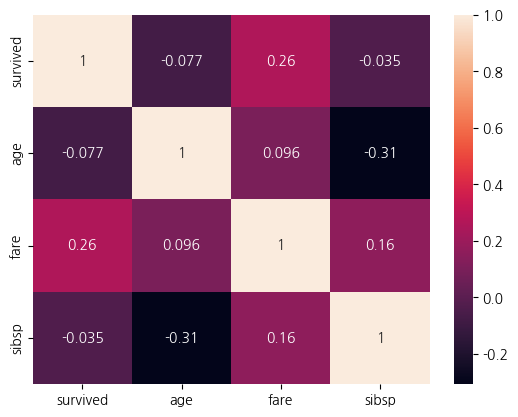

In [64]:
# 코드 입력

sns.heatmap(data=titanic[['survived', 'age', 'fare', 'sibsp']].corr(), annot=True)
set_korean_font()
plt.show()


In [65]:
# TODO 5 (countplot): 승선 항구(embark_town)별 승객 수를 countplot으로 그리세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
sns.countplot(data=titanic, x="embark_town")
plt.show()
```

</details>

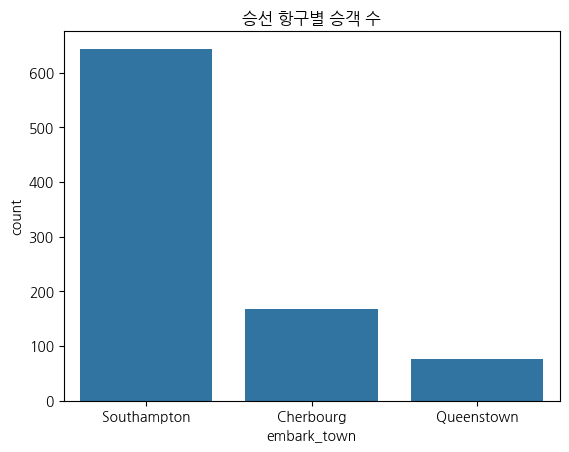

In [66]:
# 코드 입력

sns.countplot(data=titanic, x='embark_town')
plt.title("승선 항구별 승객 수")
set_korean_font()
plt.show()


In [67]:
# TODO 6 (violinplot): 좌석 등급별 요금 분포를 violinplot으로 그리고, boxplot 결과와 비교해보세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
sns.violinplot(data=titanic, x="pclass", y="fare")
plt.show()

sns.boxplot(data=titanic, x="pclass", y="fare")
plt.show()
```

</details>

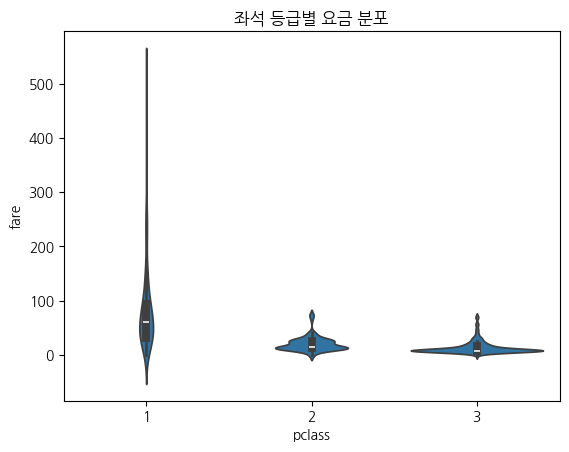

In [68]:
# 코드 입력

sns.violinplot(data=titanic, x='pclass', y='fare')
plt.title("좌석 등급별 요금 분포")
set_korean_font()
plt.show()


---

## 📝 실습 과제

In [69]:
# 과제 1: 나이 분포를 histplot으로 그리되, kde=True로 분포 곡선을 함께 표시하세요

In [70]:
# 과제 2: Matplotlib의 plt.bar()와 Seaborn의 sns.barplot()으로
#         "성별 생존율" 막대그래프를 각각 그려 비교하세요

In [71]:
# 과제 3: 나이, 요금, 형제자매수 세 컬럼을 pairplot으로 그리되,
#         hue="survived" 옵션으로 생존 여부별 색 구분까지 적용하세요 (결측치는 dropna로 먼저 제거)

**예시 정답**

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
sns.histplot(data=titanic, x="age", bins=20, kde=True)
plt.title("나이 분포 (KDE 포함)")
plt.show()
```

</details>

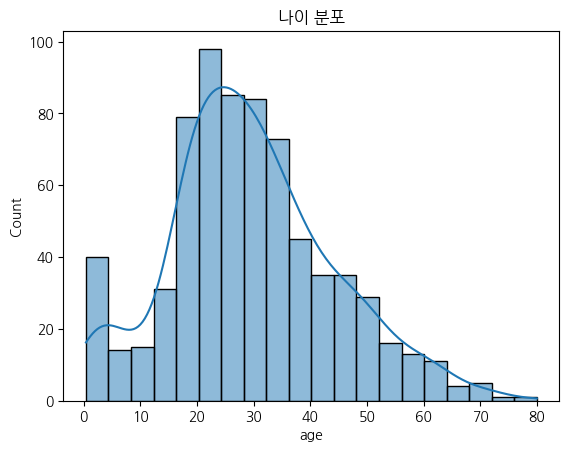

In [72]:
# 과제 1 예시 정답

sns.histplot(data=titanic, x='age', bins=20, kde=True)
plt.title("나이 분포")
set_korean_font()
plt.show()



<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
# Matplotlib 버전
grouped = titanic.groupby("sex")["survived"].mean()
plt.bar(grouped.index, grouped.values)
plt.title("성별 생존율 (Matplotlib)")
plt.show()

# Seaborn 버전
sns.barplot(data=titanic, x="sex", y="survived")
plt.title("성별 생존율 (Seaborn)")
plt.show()
```

</details>

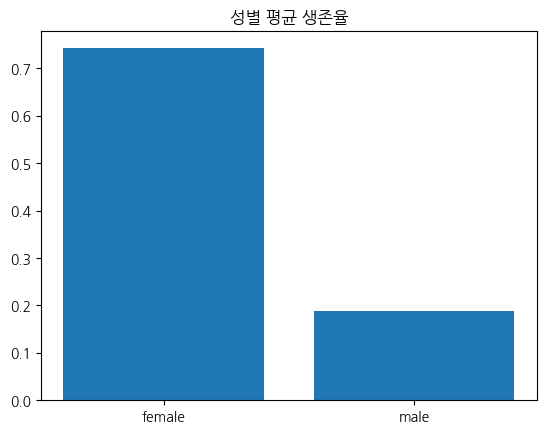

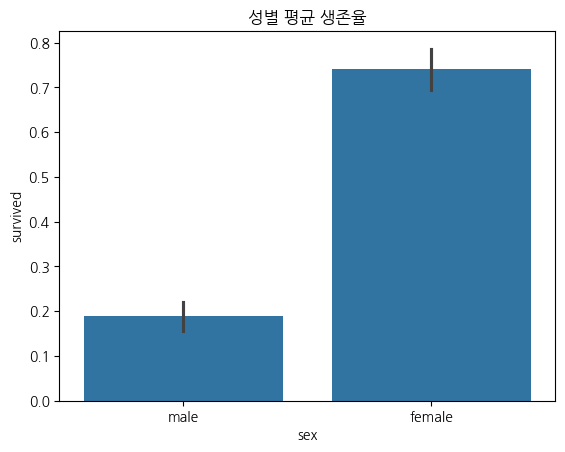

In [73]:
# 과제 2 예시 정답

# Matplotlib 버전
plt.bar(titanic.groupby('sex')['survived'].mean().index, titanic.groupby('sex')['survived'].mean().values)
plt.title("성별 평균 생존율")
set_korean_font()
plt.show()


# Seaborn 버전
sns.barplot(data=titanic, x='sex', y='survived')
plt.title("성별 평균 생존율")
set_korean_font()
plt.show()



<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 3 예시 정답
clean = titanic[["age", "fare", "sibsp", "survived"]].dropna()
sns.pairplot(clean, hue="survived")
plt.show()
```

</details>

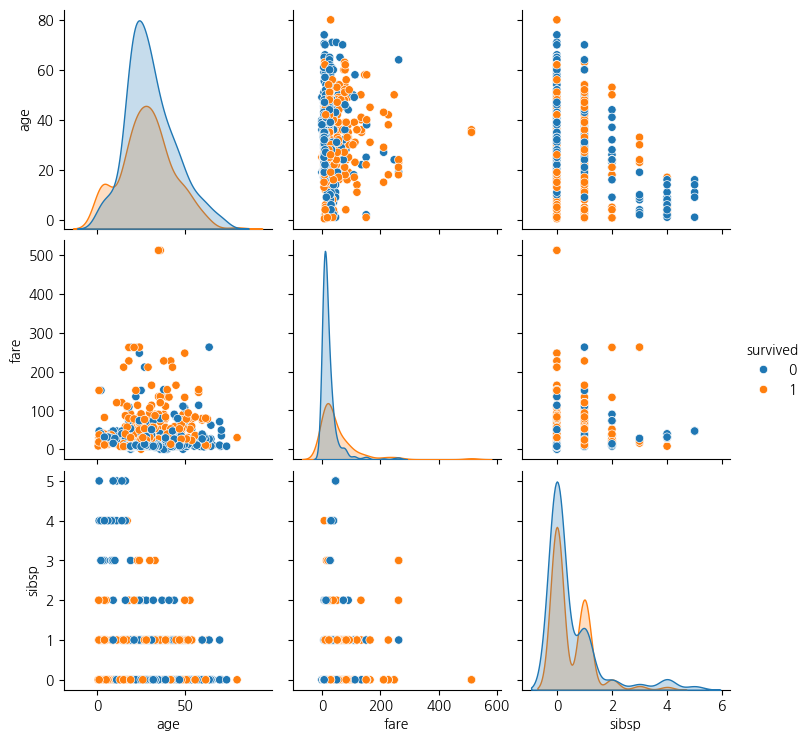

In [74]:
# 과제 3 예시 정답

sns.pairplot(data=titanic[['age', 'fare', 'sibsp', 'survived']].dropna(), hue='survived')
set_korean_font()
plt.show()



---

## 📌 핵심 정리

- Seaborn은 Matplotlib 기반, DataFrame + 컬럼명만으로 통계 그래프를 간결하게 생성
- `barplot()`: 그룹별 평균 / `countplot()`: 그룹별 빈도(개수) / `lineplot()`: 추세
- `scatterplot()`: 관계(+hue로 카테고리 구분) / `histplot()`: 분포
- `boxplot()`: 분포+이상치 요약 / `violinplot()`: 분포의 밀도 모양까지 표시
- `heatmap()`: 상관관계(숫자 요약) / `pairplot()`: 여러 변수 쌍의 산점도·분포 한 번에
- Seaborn도 결국 `plt.show()`, `plt.title()` 등 Matplotlib 문법과 함께 사용됨

---

---

# 📘 CH08-03. subplot과 스타일 설정

## 🤔 먼저 생각해보기

> **"좌석 등급별 승객 수"와 "좌석 등급별 생존율"을 각각 다른 그래프로 그리고 싶은데, 보고서 한 페이지에 나란히 배치하려면 어떻게 해야 할까요?**

여러 개의 그래프를 하나의 화면(Figure) 안에 격자 형태로 배치하고 싶을 때 사용하는 것이 **subplot**입니다. 또한 그래프 전체의 색감이나 분위기를 통일하는 **스타일 설정** 방법도 함께 배웁니다.

---

## 📖 핵심 개념

### 0) 실습 데이터 준비

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

titanic = pd.read_csv("titanic.csv")
class_counts = titanic["pclass"].value_counts().sort_index()
class_survival = titanic.groupby("pclass")["survived"].mean()
```

</details>

In [75]:
# 코드 입력

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

titanic = pd.read_csv("titanic.csv")

class_counts = titanic["pclass"].value_counts().sort_index()
class_survival = titanic.groupby("pclass")["survived"].mean()

### 1) `plt.subplot()` — 격자 하나씩 지정하는 전통적인 방식

문법: `plt.subplot(행개수, 열개수, 몇번째)`

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)          # 1행 2열 중 첫 번째
plt.bar(class_counts.index, class_counts.values)
plt.title("좌석 등급별 승객 수")

plt.subplot(1, 2, 2)          # 1행 2열 중 두 번째
plt.bar(class_survival.index, class_survival.values)
plt.title("좌석 등급별 생존율")

plt.tight_layout()
plt.show()
```

</details>

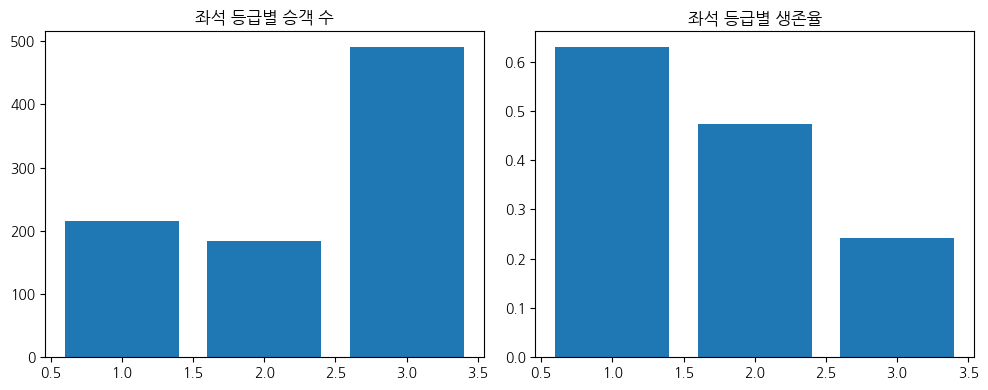

In [76]:
# 코드 입력
# 도화지 그리기
plt.figure(figsize=(10,4))

# 첫번째 그래프 (좌석 등급별 승객 수)
plt.subplot(1,2,1)  # 1행 2열 중 첫 번째
plt.bar(class_counts.index, class_counts.values)
plt.title("좌석 등급별 승객 수")

# 두 번째 그래프 (좌석 등급별 생존율)
plt.subplot(1,2,2)  # 1행 2열 중 두 번째
plt.bar(class_survival.index, class_survival.values)
plt.title("좌석 등급별 생존율")

plt.tight_layout()
set_korean_font()
plt.show()

### 2) `plt.subplots()` — Axes 배열을 한 번에 생성 (권장 방식)

문법: `fig, ax = plt.subplots(행개수, 열개수)`

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(10, 4))   # axes는 그래프 영역들의 배열

axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_title("좌석 등급별 승객 수")

axes[1].bar(class_survival.index, class_survival.values)
axes[1].set_title("좌석 등급별 생존율")

plt.tight_layout()
plt.show()
```

</details>

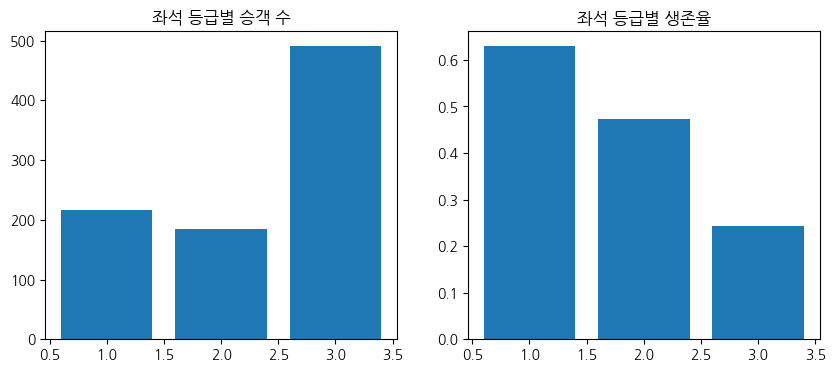

In [77]:
# axes는 그래프 영역들의 배열
# 1행 2열

fig, axes = plt.subplots(1, 2, figsize = (10,4))

axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_title("좌석 등급별 승객 수")
axes[1].bar(class_survival.index, class_survival.values)
axes[1].set_title("좌석 등급별 생존율")
set_korean_font()
plt.show()

**2행 2열처럼 더 복잡한 격자도 가능**

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].bar(class_counts.index, class_counts.values)
axes[0, 0].set_title("좌석 등급별 승객 수")

axes[0, 1].bar(class_survival.index, class_survival.values)
axes[0, 1].set_title("좌석 등급별 생존율")

axes[1, 0].scatter(titanic["age"], titanic["fare"])
axes[1, 0].set_title("나이 vs 요금 (산점도)")

axes[1, 1].hist(titanic["age"].dropna(), bins=15)
axes[1, 1].set_title("나이 분포 (히스토그램)")

plt.tight_layout()
plt.show()
```

</details>

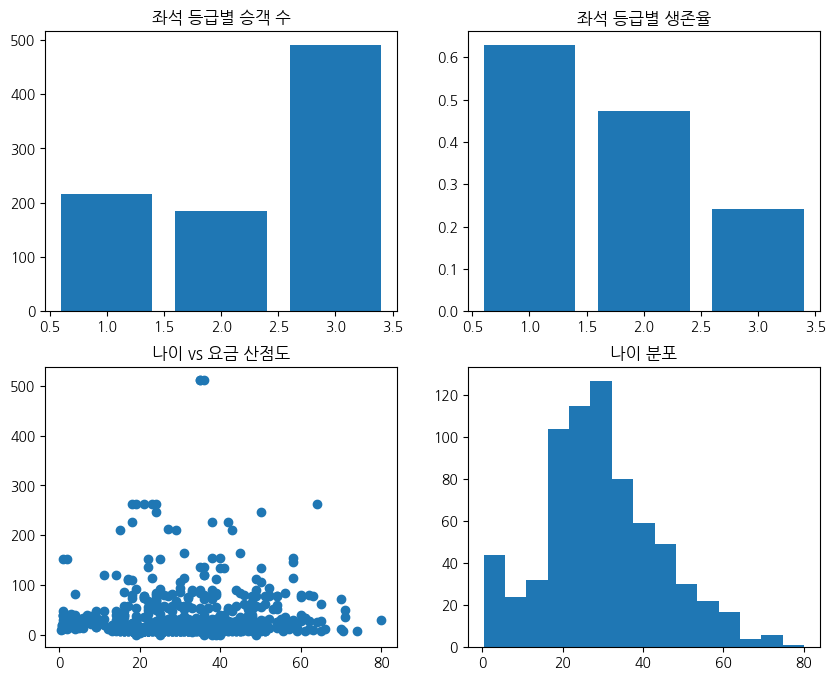

In [78]:
# 코드 입력

fig, axes = plt.subplots(2, 2, figsize=(10,8))

axes[0,0].bar(class_counts.index, class_counts.values)
axes[0,0].set_title("좌석 등급별 승객 수")

axes[0,1].bar(class_survival.index, class_survival.values)
axes[0,1].set_title("좌석 등급별 생존율")

axes[1,0].scatter(titanic['age'], titanic['fare'])
axes[1,0].set_title("나이 vs 요금 산점도")

axes[1,1].hist(titanic['age'].dropna(), bins=15)
axes[1,1].set_title("나이 분포")

set_korean_font()
plt.show()

### 3) 서로 다른 방식 비교 — `plt.subplot()` vs `plt.subplots()`

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 방법 A: subplot() — 그래프마다 매번 subplot()을 새로 호출해야 함
plt.subplot(1, 2, 1)
plt.bar(class_counts.index, class_counts.values)
plt.subplot(1, 2, 2)
plt.bar(class_survival.index, class_survival.values)
plt.tight_layout()
plt.show()
```

</details>

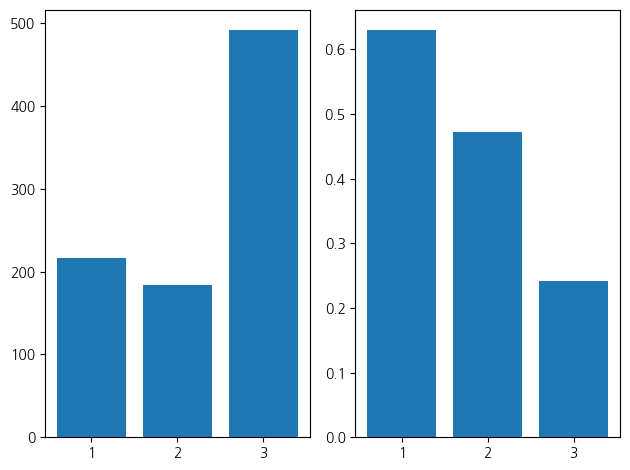

In [79]:
# 방법 A: subplot() — 그래프마다 매번 subplot()을 새로 호출해야 함

plt.subplot(1, 2, 1)
plt.bar(class_counts.index, class_counts.values)
plt.subplot(1, 2, 2)
plt.bar(class_survival.index, class_survival.values)
plt.tight_layout()
set_korean_font()
plt.show()

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 방법 B: subplots() — 한 번에 Figure와 Axes 배열을 만들고, 배열 인덱싱으로 접근
fig, axes = plt.subplots(1, 2)
axes[0].bar(class_counts.index, class_counts.values)
axes[1].bar(class_survival.index, class_survival.values)
plt.tight_layout()
plt.show()
```

</details>

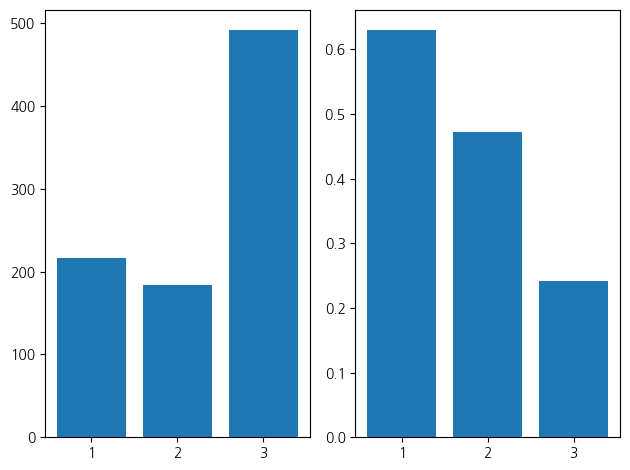

In [80]:
# 방법 B: subplots() — 한 번에 Figure와 Axes 배열을 만들고, 배열 인덱싱으로 접근

fig, axes = plt.subplots(1, 2)

axes[0].bar(class_counts.index, class_counts.values)
axes[1].bar(class_survival.index, class_survival.values)

# 그래프가 겹치지 않게 간격 자동 조정
plt.tight_layout()
set_korean_font()
plt.show()

| 구분 | `plt.subplot()` | `plt.subplots()` |
|---|---|---|
| 생성 방식 | 그래프 영역을 하나씩 순차 지정 | Figure + Axes 배열을 한 번에 생성 |
| 접근 방법 | 매번 `plt.subplot()` 재호출 | `axes[i]` 또는 `axes[i, j]`로 인덱싱 |
| 코드 재사용성 | 낮음 (반복 호출) | 높음 (반복문과 결합하기 좋음) |
| 권장 상황 | 그래프 1~2개, 간단한 배치 | 그래프 여러 개, 반복적인 배치 |

> 💡 **핵심 요약**: 그래프가 2개를 넘어가거나 반복문으로 여러 그래프를 그려야 한다면 `plt.subplots()`를 사용하세요.

### 4) 스타일 설정 — `plt.style.use()`, `sns.set_style()`

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
print(plt.style.available[:5])   # 사용 가능한 스타일 목록 일부 확인

plt.style.use("ggplot")           # ggplot 스타일 적용
plt.bar(class_survival.index, class_survival.values)
plt.title("ggplot 스타일")
plt.show()

plt.style.use("default")          # 기본 스타일로 되돌리기
```

</details>

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh']


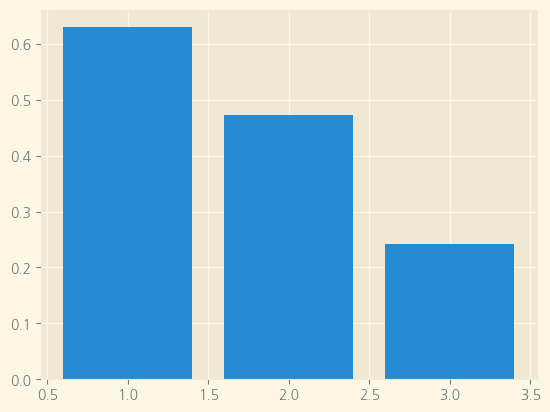

In [81]:
# 사용 가능한 스타일 목록 일부 확인
print(plt.style.available[:5])

# ggplot 스타일 적용
# 다른 스타일 적용 시 폰트 깨짐
# 스타일 먼저 적용 후 폰트 설정 필요

plt.style.use('Solarize_Light2')
plt.bar(class_survival.index, class_survival.values)
# 스타일 변경 후 한글 폰트 다시 적용
set_korean_font()

In [82]:
# 폰트 깨짐 현상 방지를 위해 한글 폰트 설정 함수 호출
set_korean_font()

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# Seaborn 스타일 설정
sns.set_style("whitegrid")   # 흰 배경 + 격자
sns.barplot(x=class_survival.index, y=class_survival.values)
plt.title("whitegrid 스타일")
plt.show()

sns.set_style("white")       # 격자 없는 흰 배경으로 되돌리기
```

</details>

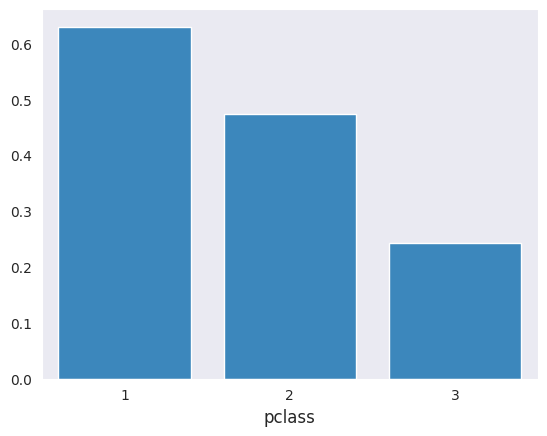

In [83]:
# Seaborn 스타일 설정
# 흰 배경 + 격자
# sns.set_style("whitegrid")

# 어두운 배경 + 격자 없음
sns.set_style("dark")

sns.barplot(x = class_survival.index, y = class_survival.values)
# 스타일 변경 후 한글 폰트 다시 적용
set_korean_font()

### 5) 색상과 팔레트

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
plt.bar(class_survival.index, class_survival.values, color="#FF5733")   # 색상 코드(hex)로 직접 지정
plt.show()
```

</details>

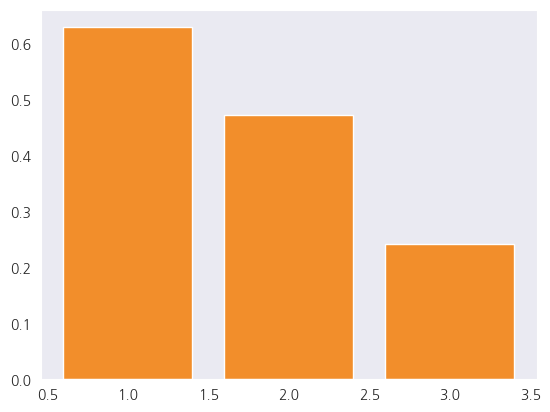

In [84]:
# 코드 입력
# 색상 코드(hex)로 직접 지정
# 파란색 #4E79A7, 초록색 #59A14F, 오렌지 #F28E2B

plt.bar(class_survival.index, class_survival.values, color='#F28E2B')
set_korean_font()
plt.show()

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# Seaborn 팔레트 활용
palette = sns.color_palette("pastel", 3)   # 3가지 파스텔톤 색상 (좌석 등급 개수만큼)
sns.barplot(data=titanic, x="pclass", y="survived", hue="pclass", palette=palette, legend=False)
plt.show()
```

</details>

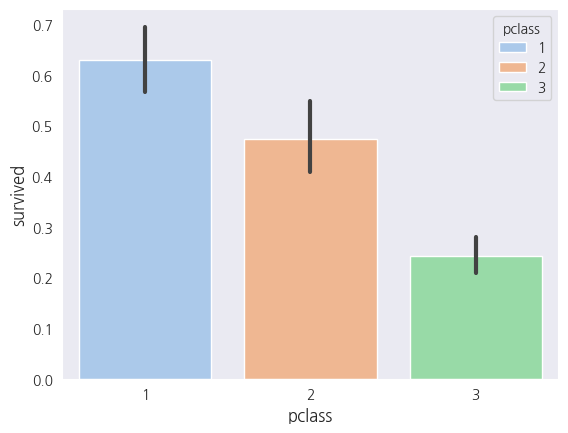

In [85]:
# Seaborn 팔레트 활용
# 3가지 파스텔톤 색상 (좌석 등급 개수만큼)
# 개수가 안맞더라도 실행은 가능
palette = sns.color_palette("pastel",3)

# 그래프 그리기
# legend = False 하면 범례 사라짐
sns.barplot(data=titanic, x='pclass', y='survived', hue='pclass', palette=palette)
set_korean_font()
plt.show()

### 6) 전체 제목과 간격 정리 — `suptitle()`, `tight_layout()`

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_title("좌석 등급별 승객 수")           # 각 그래프의 개별 제목
axes[1].bar(class_survival.index, class_survival.values)
axes[1].set_title("좌석 등급별 생존율")

fig.suptitle("타이타닉 좌석 등급 리포트", fontsize=16)   # Figure 전체를 아우르는 큰 제목
plt.tight_layout()                                       # 제목·라벨이 겹치지 않게 간격 자동 조정
plt.show()
```

</details>

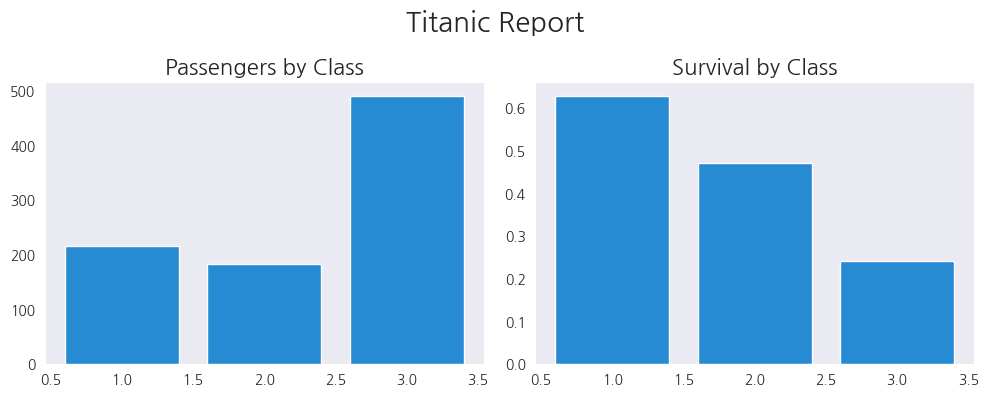

In [86]:
# 코드 입력
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(class_counts.index, class_counts.values)

# 각 그래프의 개별 제목
axes[0].set_title("Passengers by Class")
axes[1].bar(class_survival.index, class_survival.values)
axes[1].set_title("Survival by Class")

# 전체를 아우르는 큰 제목
fig.suptitle('Titanic Report', fontsize=20)

# 제목·라벨이 겹치지 않게 간격 자동 조정
plt.tight_layout()
set_korean_font()
plt.show()


> 💡 `set_title()`이 각 그래프(Axes)의 제목이라면, `fig.suptitle()`은 여러 그래프를 아우르는 **전체 보고서 제목**입니다. `tight_layout()`은 제목·축 라벨이 서로 겹치는 것을 자동으로 정리해주므로, subplot을 쓸 때는 마지막에 습관처럼 붙이는 것이 좋습니다.

### 7) 이중 축 — `twinx()` (단위가 다른 두 지표를 한 그래프에)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.bar(class_counts.index, class_counts.values, color="steelblue", alpha=0.5, label="승객 수")
ax1.set_ylabel("승객 수", color="steelblue")

ax2 = ax1.twinx()                       # x축은 공유하고 y축만 오른쪽에 하나 더 생성
ax2.plot(class_survival.index, class_survival.values, color="tomato", marker="o", label="생존율")
ax2.set_ylabel("생존율", color="tomato")
ax2.set_ylim(0, 1)

plt.title("좌석 등급별 승객 수와 생존율 함께 보기")
plt.xticks([1, 2, 3])
plt.show()
```

</details>

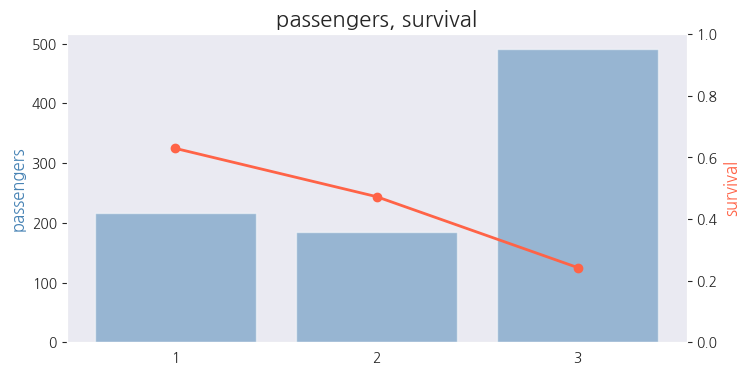

In [87]:
# 코드 입력

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.bar(class_counts.index, class_counts.values, color="steelblue", alpha=0.5, label="승객 수")
ax1.set_ylabel("passengers", color="steelblue")

ax2 = ax1.twinx() # x축은 공유하고 y축만 오른쪽에 하나 더 생성
ax2.plot(class_survival.index, class_survival.values, color="tomato", marker="o", label="생존율")
ax2.set_ylabel("survival", color="tomato")
ax2.set_ylim(0, 1)

plt.title("passengers, survival")
plt.xticks([1, 2, 3])
set_korean_font()
plt.show()

> 💡 승객 수(200 - 500명)와 생존율(0~1 사이 비율)처럼 **값의 범위(단위)가 완전히 다른 두 지표**를 한 y축에 그리면 한쪽이 바닥에 붙어 안 보입니다. `twinx()`는 x축은 공유하면서 오른쪽에 별도의 y축을 하나 더 만들어, "승객이 가장 많은 3등석이 생존율은 가장 낮다"는 대비를 한 그래프에서 확인할 수 있게 해줍니다.

---

## ⚠️ 자주 하는 실수

> ⚠️ `subplots(2, 2)`로 만든 `axes`가 2차원 배열이라는 것을 잊고 `axes[0]`처럼 1차원으로 접근해 에러가 나는 경우가 있습니다 — `axes[0, 0]`처럼 행·열을 모두 지정해야 합니다.

> ⚠️ `plt.style.use()`에 존재하지 않는 스타일 이름을 입력해 에러가 나는 경우가 있습니다 — `plt.style.available`로 미리 확인하는 습관이 좋습니다.

> ⚠️ `twinx()`로 만든 이중 축 그래프에서 두 y축의 색·라벨을 구분하지 않으면 어느 축이 어느 지표인지 알 수 없게 됩니다 — `set_ylabel(color=)`로 축마다 색을 맞춰주세요.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
fig, axes = plt.subplots(2, 2)
# axes[0].bar(...)     # ❌ 2x2 배열인데 1차원처럼 접근하면 에러
axes[0, 0].bar(class_counts.index, class_counts.values)   # ✅ 행, 열을 모두 지정
plt.tight_layout()
plt.show()
```

</details>

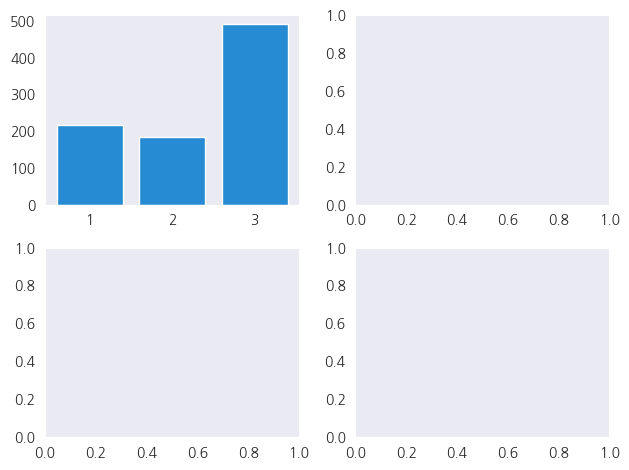

In [88]:
# 코드 입력

fig, axes = plt.subplots(2, 2)

# ❌ 2x2 배열인데 1차원처럼 접근하면 에러
# axes[0].bar(...)
axes[0, 0].bar(class_counts.index, class_counts.values)   # ✅ 행, 열을 모두 지정
plt.tight_layout()
set_korean_font()
plt.show()

---

## 🚀 실무에서는?

> 🚀 실무 보고서나 대시보드에서는 여러 지표(인원수, 생존율, 상관관계 등)를 한 화면에 정리해서 보여주는 경우가 많습니다. `subplots()`로 격자를 만들고, `suptitle()`로 전체 제목을, `tight_layout()`으로 깔끔한 배치를 하는 조합이 표준적인 패턴입니다.

---

## 🧩 Check Point

**Q1.** `subplots(2, 2)`로 만든 `axes`에서 두 번째 행, 첫 번째 열에 접근하는 방법은? ① `axes[1]` ② `axes[1, 0]` ③ `axes[0, 1]` ④ `axes(1,0)`
<details><summary>정답</summary>② `axes[1, 0]`</details>

**Q2.** 여러 그래프의 제목/레이블이 겹치지 않게 자동으로 간격을 조정하는 함수는? ① `plt.show()` ② `plt.tight_layout()` ③ `plt.figure()` ④ `plt.style.use()`
<details><summary>정답</summary>② `plt.tight_layout()`</details>

**Q3.** 승객 수와 생존율처럼 단위가 다른 두 지표를 한 그래프에 그릴 때, x축은 공유하고 y축을 하나 더 만드는 방법은? ① `subplots()` ② `twinx()` ③ `suptitle()` ④ `axhline()`
<details><summary>정답</summary>② `twinx()`</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. 난이도가 단계적으로 올라갑니다.

In [89]:
# TODO 1 (subplot 기본): 좌석 등급별 승객 수 막대그래프와 생존율 막대그래프를 1행 2열로 나란히 그리세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(class_counts.index, class_counts.values)
plt.title("승객 수")
plt.subplot(1, 2, 2)
plt.bar(class_survival.index, class_survival.values)
plt.title("생존율")
plt.tight_layout()
plt.show()
```

</details>

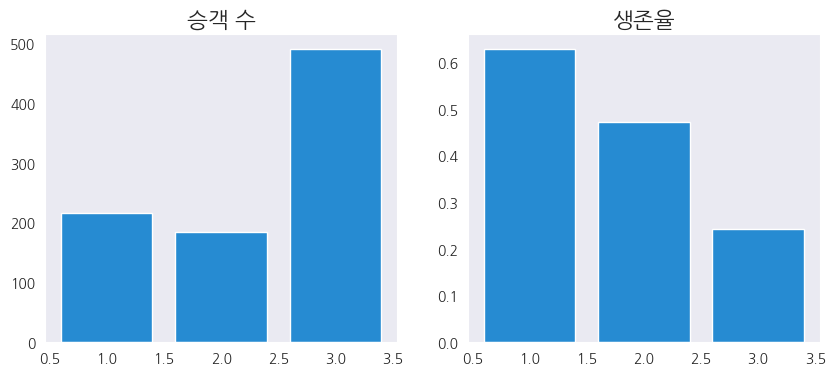

In [90]:
# 코드 입력

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(class_counts.index, class_counts.values)
plt.title("승객 수")

plt.subplot(1,2,2)
plt.bar(class_survival.index, class_survival.values)
plt.title("생존율")

set_korean_font()
plt.show()

In [91]:
# TODO 2 (subplots 기본): 위와 같은 그래프를 subplots()로 다시 그려보세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_title("승객 수")
axes[1].bar(class_survival.index, class_survival.values)
axes[1].set_title("생존율")
plt.tight_layout()
plt.show()
```

</details>

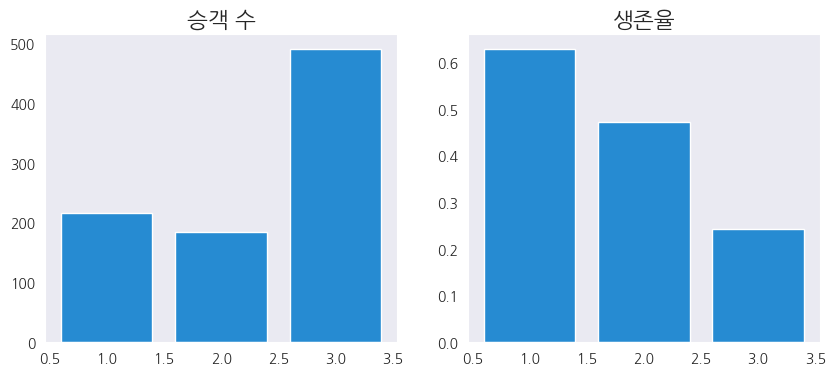

In [92]:
# 코드 입력

fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_title("승객 수")

axes[1].bar(class_survival.index, class_survival.values)
axes[1].set_title("생존율")

plt.show()

In [93]:
# TODO 3 (2x2 격자): 4개의 서로 다른 그래프(bar, scatter, hist, box)를 2x2로 배치하세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].bar(class_survival.index, class_survival.values)
axes[0, 0].set_title("생존율 (bar)")
axes[0, 1].scatter(titanic["age"], titanic["fare"])
axes[0, 1].set_title("나이 vs 요금 (scatter)")
axes[1, 0].hist(titanic["age"].dropna(), bins=15)
axes[1, 0].set_title("나이 분포 (hist)")
sns.boxplot(data=titanic, x="pclass", y="fare", ax=axes[1, 1])
axes[1, 1].set_title("등급별 요금 (box)")
plt.tight_layout()
plt.show()
```

</details>

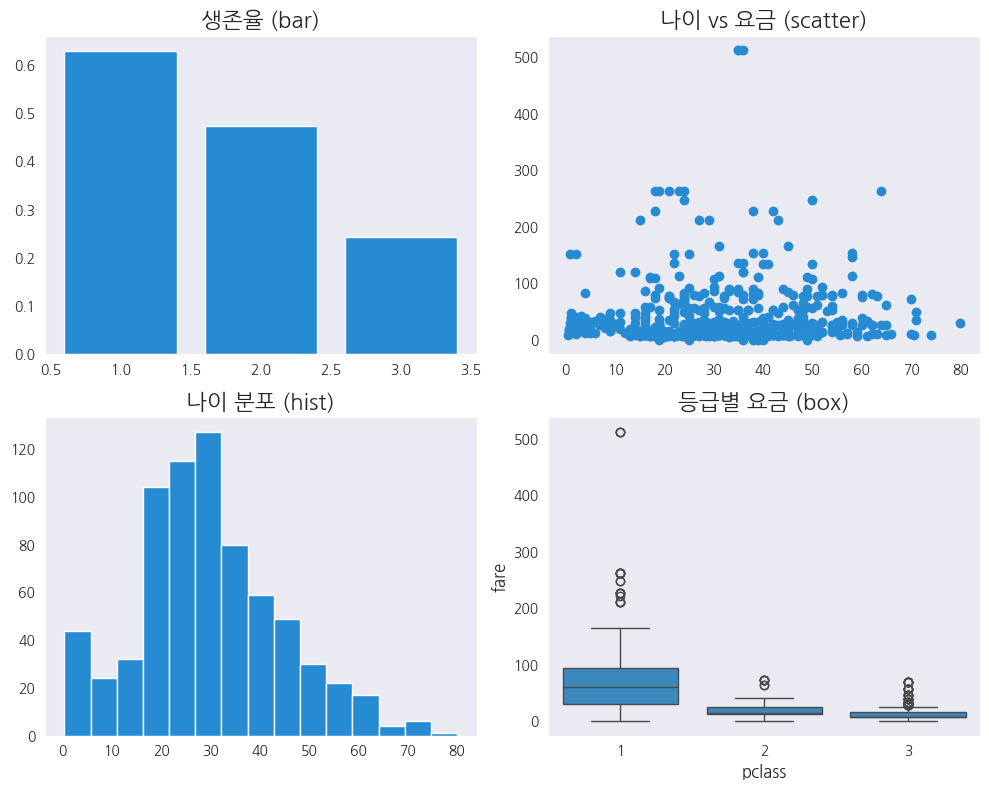

In [94]:
# 코드 입력

fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes[0,0].bar(class_survival.index, class_survival.values)
axes[0,0].set_title("생존율 (bar)")

axes[0,1].scatter(titanic["age"], titanic["fare"])
axes[0,1].set_title("나이 vs 요금 (scatter)")

axes[1,0].hist(titanic["age"].dropna(), bins=15)
axes[1,0].set_title("나이 분포 (hist)")

sns.boxplot(data=titanic, x="pclass", y="fare", ax=axes[1,1])
axes[1,1].set_title("등급별 요금 (box)")

plt.tight_layout()
set_korean_font()


In [95]:
# TODO 4 (스타일+팔레트): whitegrid 스타일과 pastel 팔레트를 적용해 성별 생존율 막대그래프를 그리세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
sns.set_style("whitegrid")
sex_survival = titanic.groupby("sex")["survived"].mean()
sns.barplot(x=sex_survival.index, y=sex_survival.values, hue=sex_survival.index,
            palette=sns.color_palette("pastel", 2), legend=False)
plt.title("성별 생존율")
plt.show()
sns.set_style("white")
```

</details>

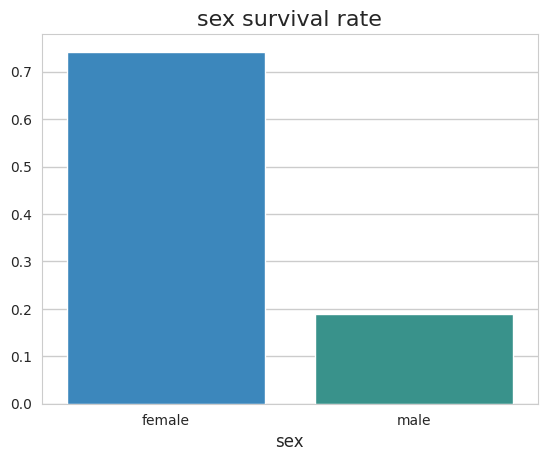

In [96]:
sns.set_style("whitegrid")
sex_survival = titanic.groupby("sex")["survived"].mean()

sns.barplot(x=sex_survival.index, y=sex_survival.values, hue=sex_survival.index)
plt.title("sex survival rate")
set_korean_font()
plt.show()

In [97]:
# TODO 5 (twinx): 승선 항구별 승객 수(막대)와 생존율(선)을 twinx() 이중 축으로 한 그래프에 그리고,
#         fig.suptitle()로 전체 제목을 붙이세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
embark_counts = titanic["embark_town"].value_counts()
embark_survival = titanic.groupby("embark_town")["survived"].mean()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(embark_counts.index, embark_counts.values, color="steelblue", alpha=0.5)
ax1.set_ylabel("승객 수", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(embark_survival.index, embark_survival.reindex(embark_counts.index).values,
         color="tomato", marker="o")
ax2.set_ylabel("생존율", color="tomato")
ax2.set_ylim(0, 1)

fig.suptitle("승선 항구별 승객 수·생존율")
plt.tight_layout()
plt.show()
```

</details>

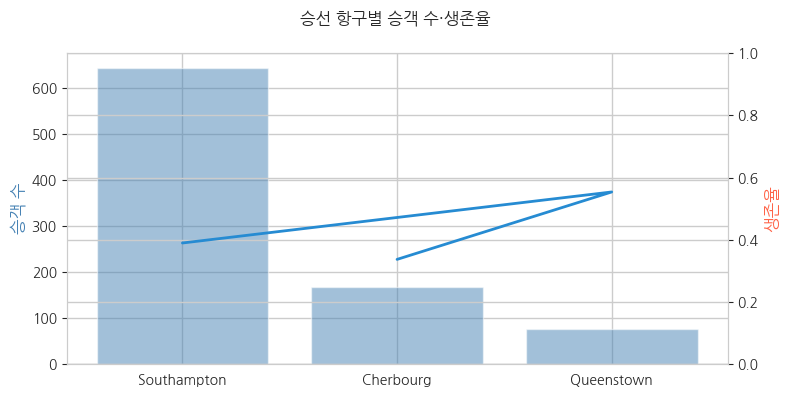

In [98]:
# 코드 입력

embark_counts = titanic["embark_town"].value_counts()
embark_survival = titanic.groupby("embark_town")["survived"].mean()

fig, ax1 = plt.subplots(figsize=(8,4))
ax1.bar(embark_counts.index, embark_counts.values, color="steelblue", alpha=0.5)
ax1.set_ylabel("승객 수", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(embark_survival.index, embark_survival.reindex(embark_counts.index).values)
ax2.set_ylabel("생존율", color="tomato")
ax2.set_ylim(0,1)

fig.suptitle("승선 항구별 승객 수·생존율")
plt.tight_layout()
set_korean_font()
plt.show()


---

## 📝 실습 과제

In [99]:
# 과제 1: 1행 3열 subplots()로 "등급별 승객 수", "등급별 생존율", "요금 히스토그램"을 배치하세요

In [100]:
# 과제 2: 2x1 구조로 성별 생존율(barplot)과 성별 나이 분포(boxplot)를
#         위아래로 배치하고 suptitle을 붙이세요

In [101]:
# 과제 3: 1행 2열 subplots()에 왼쪽엔 승객 수+생존율 twinx() 이중 축 그래프,
#         오른쪽엔 요금 히스토그램을 배치하고 suptitle과 tight_layout을 적용하세요

**예시 정답**

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_title("등급별 승객 수")
axes[1].bar(class_survival.index, class_survival.values)
axes[1].set_title("등급별 생존율")
axes[2].hist(titanic["fare"], bins=15)
axes[2].set_title("요금 분포")
plt.tight_layout()
plt.show()
```

</details>

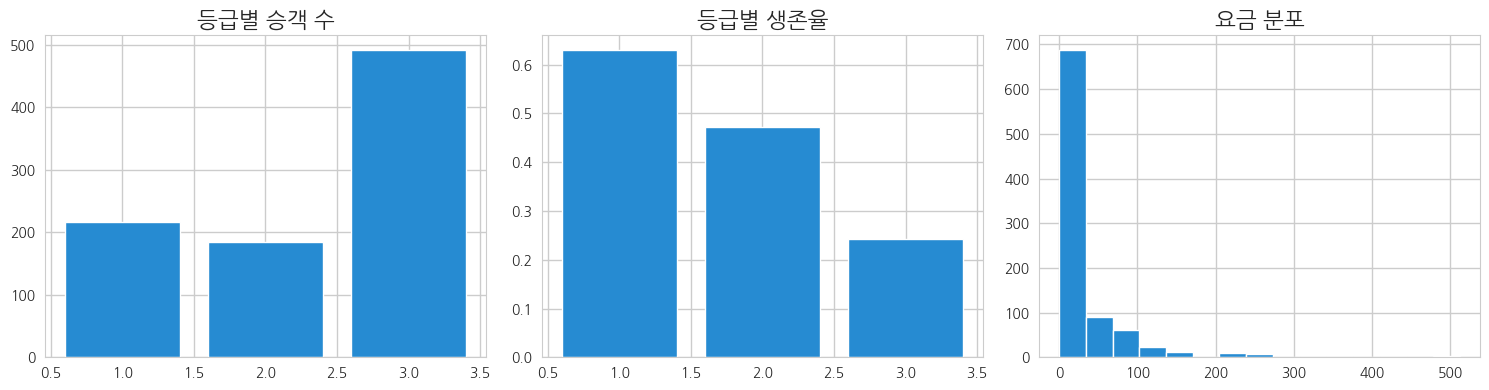

In [102]:
# 과제 1 예시 정답

fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_title("등급별 승객 수")

axes[1].bar(class_survival.index, class_survival.values)
axes[1].set_title("등급별 생존율")

axes[2].hist(titanic["fare"], bins=15)
axes[2].set_title("요금 분포")

plt.tight_layout()
set_korean_font()
plt.show()


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
fig, axes = plt.subplots(2, 1, figsize=(7, 8))
sns.barplot(data=titanic, x="sex", y="survived", ax=axes[0])
axes[0].set_title("성별 생존율")
sns.boxplot(data=titanic, x="sex", y="age", ax=axes[1])
axes[1].set_title("성별 나이 분포")
fig.suptitle("성별 리포트", fontsize=15)
plt.tight_layout()
plt.show()
```

</details>

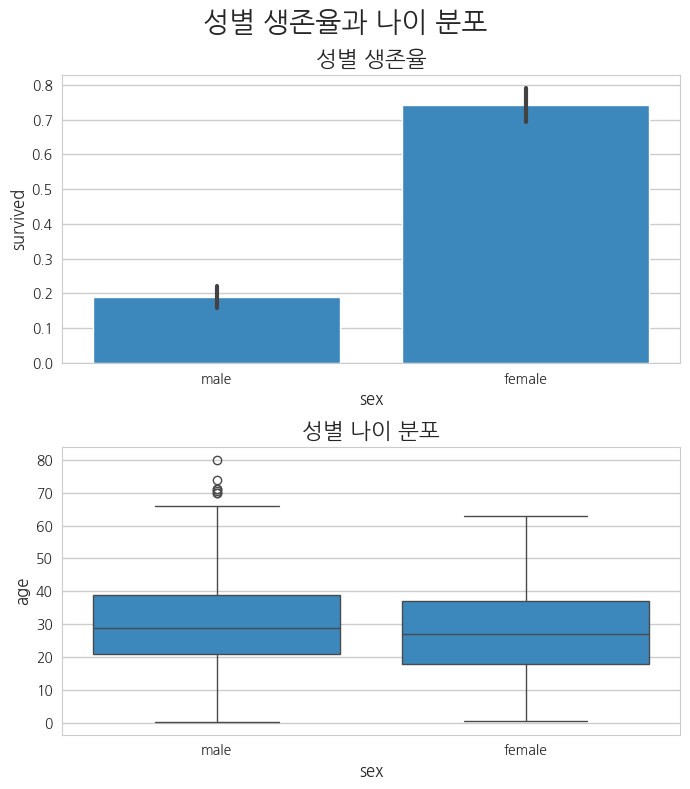

In [103]:
# 과제 2 예시 정답

fig, axes = plt.subplots(2, 1, figsize=(7,8))
sns.barplot(data=titanic, x="sex", y="survived", ax=axes[0])
axes[0].set_title("성별 생존율")

sns.boxplot(data=titanic, x="sex", y="age", ax=axes[1])
axes[1].set_title("성별 나이 분포")

fig.suptitle("성별 생존율과 나이 분포", fontsize=20)
plt.tight_layout()
set_korean_font()
plt.show()


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 3 예시 정답
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(class_counts.index, class_counts.values, color="steelblue", alpha=0.5)
axes[0].set_ylabel("승객 수", color="steelblue")
ax_twin = axes[0].twinx()
ax_twin.plot(class_survival.index, class_survival.values, color="tomato", marker="o")
ax_twin.set_ylabel("생존율", color="tomato")
ax_twin.set_ylim(0, 1)
axes[0].set_title("승객 수·생존율")

axes[1].hist(titanic["fare"], bins=15, color="skyblue", edgecolor="black")
axes[1].set_title("요금 분포")

fig.suptitle("타이타닉 좌석 등급 리포트", fontsize=15)
plt.tight_layout()
plt.show()
```

</details>

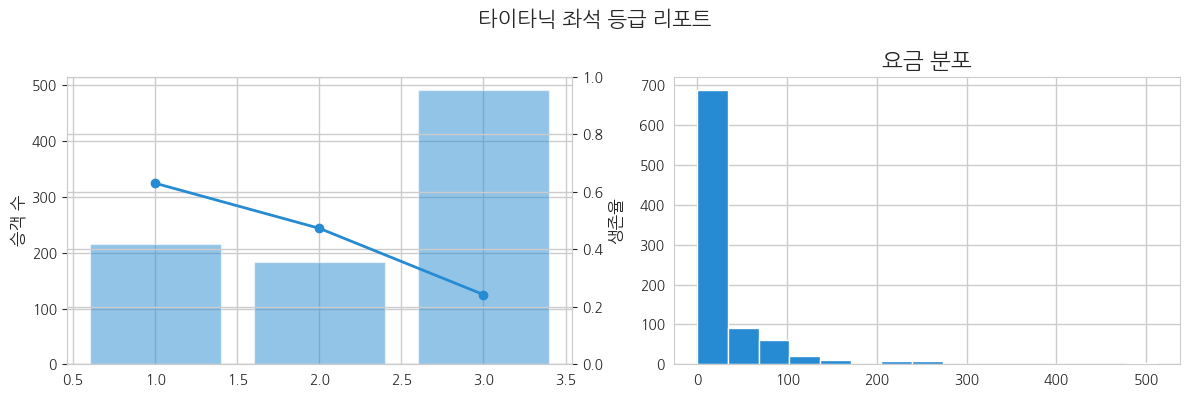

In [104]:
# 과제 3 예시 정답

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].bar(class_counts.index, class_counts.values, alpha=0.5)
axes[0].set_ylabel("승객 수")

ax_twin = axes[0].twinx()
ax_twin.plot(class_survival.index, class_survival.values, marker="o")
ax_twin.set_ylabel("생존율")
ax_twin.set_ylim(0,1)

axes[1].hist(titanic["fare"], bins=15)
axes[1].set_title("요금 분포")

fig.suptitle("타이타닉 좌석 등급 리포트", fontsize=15)
plt.tight_layout()
set_korean_font()
plt.show()


---

## 📌 핵심 정리

- `plt.subplot(행,열,순서)`: 그래프 영역을 하나씩 순차 지정 (간단할 때)
- `plt.subplots(행,열)`: Figure와 Axes 배열을 한 번에 생성, `axes[i,j]`로 접근 (권장)
- `set_title()`: 개별 그래프 제목 / `fig.suptitle()`: Figure 전체 제목
- `plt.tight_layout()`으로 그래프 간 간격 자동 조정 (subplot 사용 시 습관처럼)
- `twinx()`: 단위가 다른 두 지표를 위한 이중 y축 (승객 수+생존율처럼)
- `plt.style.use()`, `sns.set_style()`로 전체 스타일 통일
- 팔레트(`sns.color_palette()`)로 그래프 색상 통일

---

---

# 📘 CH08-04. Plotly(소개)

## 🤔 먼저 생각해보기

> **좌석 등급별 생존율 그래프를 손가락으로 확대하거나, 특정 막대에 커서를 올리면 정확한 값이 뜨는 걸 본 적 있나요?**

Matplotlib으로 만든 그래프는 "그림"이라 확대하거나 값을 직접 확인할 수 없습니다. 마우스로 확대·축소하고, 값을 바로 확인할 수 있는 **인터랙티브(상호작용) 그래프**를 만들어주는 도구가 **Plotly**입니다.

---

## 📖 핵심 개념

### 0) 실습 데이터 준비

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import plotly.express as px   # 관례적으로 px라는 별칭 사용
import pandas as pd

titanic = pd.read_csv("titanic.csv")
class_survival = titanic.groupby("pclass", as_index=False)["survived"].mean()
print(class_survival)
```

</details>

In [105]:
# 관례적으로 px라는 별칭 사용

import plotly.express as px
import pandas as pd

titanic = pd.read_csv('titanic.csv')

# 등급별 생존율
class_survival = titanic.groupby('pclass', as_index=False)['survived'].mean()  # as_index=False
print(class_survival)



   pclass  survived
0       1  0.629630
1       2  0.472826
2       3  0.242363


### 1) Plotly란? — 인터랙티브 시각화 라이브러리

- `plotly.express`(줄여서 `px`)는 Plotly를 간단하게 쓸 수 있게 해주는 모듈
- Matplotlib과 비슷한 문법이지만, 결과물이 마우스로 조작 가능한 인터랙티브 그래프

### 2) `px.line()` — 인터랙티브 선 그래프

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
age_survival = titanic.groupby("age", as_index=False)["survived"].mean()

fig = px.line(age_survival, x="age", y="survived", title="나이에 따른 생존율 변화")
fig.show()   # 마우스를 올려보세요! 정확한 값이 표시됩니다
```

</details>

In [106]:
# 연령별 생존율
# as_index = False : 그룹으로 묶은 컬럼을 인덱스로 만들지 않고 일반 컬럼 유지

age_survival = titanic.groupby("age", as_index=False)["survived"].mean()

fig = px.line(age_survival, x="age", y="survived", title="나이에 따른 생존율 변화")
fig.show()


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 성별로 나눈 선을 한 그래프에 (wide 형태 데이터로 변환)
age_sex_survival = titanic.groupby(["age", "sex"], as_index=False)["survived"].mean()
fig = px.line(age_sex_survival, x="age", y="survived", color="sex", title="성별 나이별 생존율 비교")
fig.show()
```

</details>

In [107]:
# 성별로 나눈 선을 한 그래프에 (wide 형태 데이터로 변환)

age_sex_survival = titanic.groupby(["age", "sex"], as_index=False)["survived"].mean()

fig = px.line(age_sex_survival, x='age', y='survived', color='sex', title='성별 vs 나이별 생존율 비교')
fig.show()


### 3) `px.bar()` — 인터랙티브 막대그래프

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
fig = px.bar(class_survival, x="pclass", y="survived", title="좌석 등급별 생존율", color="pclass")
fig.show()
```

</details>

In [108]:
# 코드 입력

fig = px.bar(class_survival, x="pclass", y="survived", title="좌석 등급별 생존율", color="pclass")
fig.show()


### 4) `px.scatter()` — 인터랙티브 산점도

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
fig = px.scatter(titanic, x="age", y="fare", color="survived",
                 hover_data=["sex", "pclass"], title="나이-요금 관계 (생존 여부 색상 구분)")
fig.show()
```

</details>

In [109]:
# 코드 입력

fig = px.scatter(titanic, x="age", y="fare", color="survived",
                 hover_data=["sex", "pclass"], title="나이-요금 관계 (생존 여부 색상 구분)")
fig.show()


> 💡 `hover_data`에 지정한 컬럼은 마우스를 올렸을 때 추가 정보로 표시됩니다. `color` 옵션으로 생존 여부별로 점의 색을 자동으로 구분할 수 있습니다.

### 5) 그 외 주요 그래프 — `px.pie()`, `px.histogram()`

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
class_counts = titanic["pclass"].value_counts().reset_index()
class_counts.columns = ["pclass", "count"]

fig = px.pie(class_counts, names="pclass", values="count", title="좌석 등급별 승객 비율")
fig.show()

fig = px.histogram(titanic, x="age", nbins=20, title="승객 나이 분포")
fig.show()
```

</details>

In [110]:
# 코드 입력

class_counts = titanic["pclass"].value_counts().reset_index()
class_counts.columns = ["pclass", "count"]

fig = px.pie(class_counts, names="pclass", values="count", title="좌석 등급별 승객 비율")
fig.show()

fig = px.histogram(titanic, x="age", nbins=20, title="승객 나이 분포")
fig.show()


> 💡 Matplotlib의 `pie()`/`hist()`와 대응되는 인터랙티브 버전입니다. `px.pie()`는 조각에 마우스를 올리면 정확한 값·비율이 표시되고, `px.histogram()`은 구간별 개수를 hover로 확인할 수 있습니다.

### 6) 그래프 꾸미기 — `update_layout()`

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
fig = px.bar(class_survival, x="pclass", y="survived")
fig.update_layout(
    title="좌석 등급별 생존율",          # 제목
    xaxis_title="좌석 등급",              # x축 라벨
    yaxis_title="생존율",                 # y축 라벨
    width=700, height=400                  # 그래프 크기
)
fig.show()
```

</details>

In [111]:
# 코드 입력

fig = px.bar(class_survival, x="pclass", y="survived")
fig.update_layout(
    title="좌석 등급별 생존율",  # 제목
    xaxis_title="좌석 등급",   # x축 라벨
    yaxis_title="생존율",     # y축 라벨
    width=700, height=400   # 그래프 크기
)
fig.show()

> 💡 Matplotlib에서 `plt.title()`, `plt.xlabel()`로 하던 꾸미기를 Plotly에서는 `fig.update_layout()` 하나로 모아서 처리합니다. 만들어진 `fig` 객체에 제목·축 라벨·크기 등을 나중에 덧붙이는 방식이라는 점이 특징입니다.

### 7) 인터랙티브 기능 — hover, zoom, pan

- Plotly로 만든 그래프는 별도의 코드 없이도 기본적으로 다음 기능을 제공합니다: 마우스 오버로 값 확인, 드래그로 확대, 더블클릭으로 원래대로, 범례 클릭으로 항목 숨기기/보이기

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 방법 A: Matplotlib — 정적인 이미지, 값 확인은 눈대중
import matplotlib.pyplot as plt
plt.bar(class_survival["pclass"], class_survival["survived"])
plt.title("좌석 등급별 생존율 (Matplotlib)")
plt.show()
```

</details>

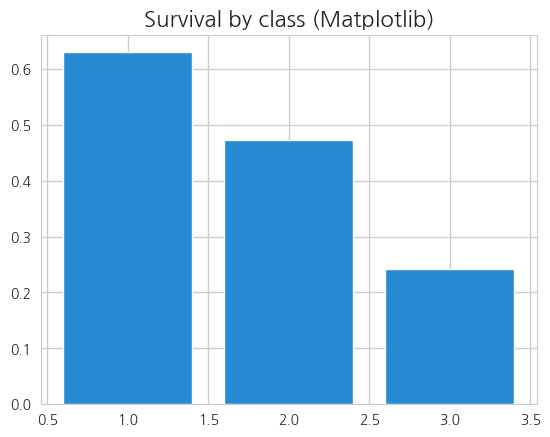

In [113]:
# 방법 A: Matplotlib — 정적인 이미지, 값 확인은 눈대중

import matplotlib.pyplot as plt
plt.bar(class_survival['pclass'], class_survival['survived'])
plt.title("Survival by class (Matplotlib)")
set_korean_font()
plt.show()

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 방법 B: Plotly — 인터랙티브, 마우스 오버로 정확한 값 확인 가능
fig = px.bar(class_survival, x="pclass", y="survived", title="좌석 등급별 생존율 (Plotly)")
fig.show()
```

</details>

In [114]:
# 방법 B: Plotly — 인터랙티브, 마우스 오버로 정확한 값 확인 가능

fig = px.bar(class_survival, x="pclass", y="survived", title="좌석 등급별 생존율 (Plotly)")
fig.show()

| 구분 | Matplotlib | Plotly |
|---|---|---|
| 결과물 형태 | 정적 이미지 | 인터랙티브 웹 요소 (hover/zoom/pan) |
| 학습 곡선 | 세밀한 커스터마이징 가능, 문법이 다소 장황 | 간결한 문법, 빠르게 예쁜 그래프 |
| 적합한 용도 | 논문, 인쇄물, 정적 보고서 | 웹 대시보드, 발표 자료, 탐색적 분석 |
| 파일로 저장 | `savefig()`로 간단히 | 별도 패키지(`kaleido`) 필요할 수 있음 |

> 💡 **핵심 요약**: 인쇄물/논문은 Matplotlib, 웹 대시보드/발표 자료는 Plotly가 적합합니다.

---

## ⚠️ 자주 하는 실수

> ⚠️ `fig.show()`를 빼먹어서 그래프가 출력되지 않는 경우가 있습니다.

> ⚠️ Plotly 그래프를 정적 이미지 파일로 저장하려면 `kaleido`라는 별도 패키지가 필요할 수 있습니다 (`fig.write_image()` 사용 시).

> ⚠️ `update_layout()`을 호출만 하고 그 결과를 다시 `fig.show()`로 출력하지 않거나, `px.bar(title=...)`과 `update_layout(title=...)`을 중복 지정해 혼란이 생기는 경우가 있습니다 — 꾸미기는 한 곳에서 일관되게 처리하세요.

---

## 🧩 Check Point

**Q1.** Plotly를 간단하게 사용할 수 있게 해주는 모듈은? ① plotly.graph_objects ② plotly.express ③ plotly.io ④ plotly.figure_factory
<details><summary>정답</summary>② plotly.express (px)</details>

**Q2.** 마우스를 올렸을 때 추가 정보를 표시하는 옵션은? ① color ② size ③ hover_data ④ title
<details><summary>정답</summary>③ hover_data</details>

**Q3.** Plotly 그래프의 제목·축 라벨·크기를 한 번에 지정하는 메서드는? ① `fig.title()` ② `fig.update_layout()` ③ `fig.set_labels()` ④ `fig.config()`
<details><summary>정답</summary>② `fig.update_layout()`</details>

---

## 💻 실습

> 🔧 아래 코드 블록은 ipynb 셀로 그대로 변환됩니다. 난이도가 단계적으로 올라갑니다.

In [115]:
# TODO 1 (px.line): 나이에 따른 생존율 변화를 인터랙티브 선 그래프로 그리세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
age_survival = titanic.groupby("age", as_index=False)["survived"].mean()
fig = px.line(age_survival, x="age", y="survived", title="나이에 따른 생존율")
fig.show()
```

</details>

In [116]:
# 코드 입력

age_survival = titanic.groupby("age", as_index=False)["survived"].mean()
fig = px.line(age_survival, x="age", y="survived", title="나이에 따른 생존율")
fig.show()


In [117]:
# TODO 2 (px.bar): 성별 생존율을 인터랙티브 막대그래프로 그리세요 (color로 성별 구분)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
sex_survival = titanic.groupby("sex", as_index=False)["survived"].mean()
fig = px.bar(sex_survival, x="sex", y="survived", color="sex")
fig.show()
```

</details>

In [130]:
# 코드 입력

sex_survival = titanic.groupby('sex', as_index=False)['survived'].mean()
fig = px.bar(sex_survival, x="sex", y="survived", color="sex")
fig.show()

In [119]:
# TODO 3 (px.scatter): 나이-요금 관계를 좌석 등급별 색상 구분과 hover 정보를 포함해 그리세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
fig = px.scatter(titanic, x="age", y="fare", color="pclass", hover_data=["sex"])
fig.show()
```

</details>

In [131]:
# 코드 입력

fig = px.scatter(titanic, x='age', y='fare', color='pclass', hover_data=['sex'])
fig.show()


In [121]:
# TODO 4 (px.pie + update_layout): 승선 항구(embark_town)별 승객 수를 px.pie()로 그리고,
#         update_layout()으로 제목과 크기(600x400)를 지정하세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
embark_counts = titanic["embark_town"].value_counts().reset_index()
embark_counts.columns = ["embark_town", "count"]
fig = px.pie(embark_counts, names="embark_town", values="count")
fig.update_layout(title="승선 항구별 승객 비율", width=600, height=400)
fig.show()
```

</details>

In [132]:
# 코드 입력

embark_counts = titanic["embark_town"].value_counts().reset_index()
embark_counts.columns = ["embark_town", "count"]
fig = px.pie(embark_counts, names="embark_town", values="count")
fig.update_layout(title="승선 항구별 승객 비율", width=600, height=400)
fig.show()


---

## 📝 실습 과제

In [123]:
# 과제 1: 나이에 따른 생존율(age_survival)로 px.line() 인터랙티브 그래프를 그리고, 특정 구간을 확대해서 값이 정확히 보이는지 확인하세요

In [124]:
# 과제 2: 좌석 등급별 평균 요금을 Matplotlib bar()와 Plotly px.bar() 두 가지로 각각 그려서
#         정적 그래프와 인터랙티브 그래프의 차이를 비교하세요

In [125]:
# 과제 3: 나이 데이터를 px.histogram()으로 그리고, update_layout()으로 제목·축 라벨을 지정하세요

**예시 정답**

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 1 예시 정답
fig = px.line(age_survival, x="age", y="survived", title="나이에 따른 생존율")
fig.show()
# 그래프 위에서 마우스로 드래그하면 원하는 구간을 확대해서 값을 정확히 확인할 수 있습니다.
```

</details>

In [133]:
# 과제 1 예시 정답

fig = px.line(age_survival, x="age", y="survived", title="나이에 따른 생존율")
fig.show()


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 2 예시 정답
class_fare = titanic.groupby("pclass")["fare"].mean()

plt.bar(class_fare.index, class_fare.values)
plt.title("좌석 등급별 평균 요금 (Matplotlib)")
plt.show()

fig = px.bar(class_fare.reset_index(), x="pclass", y="fare", title="좌석 등급별 평균 요금 (Plotly)")
fig.show()
```

</details>

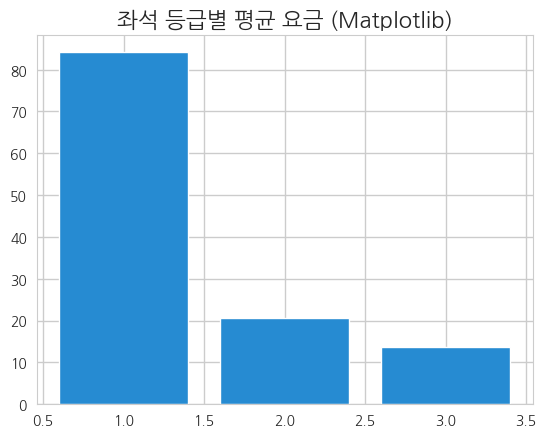

In [134]:
# 과제 2 예시 정답

class_fare = titanic.groupby("pclass")["fare"].mean()

plt.bar(class_fare.index, class_fare.values)
plt.title("좌석 등급별 평균 요금 (Matplotlib)")
plt.show()

fig = px.bar(class_fare.reset_index(), x="pclass", y="fare", title="좌석 등급별 평균 요금 (Plotly)")
fig.show()


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 과제 3 예시 정답
fig = px.histogram(titanic, x="age", nbins=20)
fig.update_layout(title="나이 분포", xaxis_title="나이", yaxis_title="승객 수")
fig.show()
```

</details>

In [137]:
# 과제 3 예시 정답

fig = px.histogram(titanic, x="age")
fig.update_layout(title="나이 분포", xaxis_title="나이", yaxis_title="승객 수")
fig.show()


---

## 📌 핵심 정리

- Plotly(`plotly.express`, `px`)는 인터랙티브(확대/hover/이동 가능) 그래프를 제공
- `px.line()`: 선 그래프 / `px.bar()`: 막대그래프 / `px.scatter()`: 산점도
- `px.pie()`: 비율 / `px.histogram()`: 분포 — Matplotlib의 pie/hist에 대응
- `color`, `size`, `hover_data` 옵션으로 추가 정보를 그래프에 자연스럽게 담을 수 있음
- `fig.update_layout()`으로 제목·축 라벨·크기를 한 곳에서 지정
- 인쇄물/논문은 Matplotlib, 웹 대시보드/발표 자료는 Plotly가 적합

---

---
## 🎉 정규 수업 완료!

Matplotlib, Seaborn, subplot/스타일, Plotly 4개 소단원을 모두 다뤘습니다. 아주 기초적인 첫 예시(2~3개 값)를 제외하고는 실제 타이타닉 승객 891명의 데이터(`titanic.csv`)를 계속 이어서 사용해, "여성과 아이 먼저", "1등석일수록 생존율이 높았다" 같은 실제 역사적 사실을 데이터로 직접 확인하며 다양한 그래프를 그리는 감각을 키웠습니다. 자율학습 심화 내용은 CH08 관련 md 문서를 참고해주세요.
